In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import importlib
import utils.event_data
importlib.reload(utils.event_data)
from utils.event_data import generate_event_frames



# -------- Usage --------
event_npz_path = r".\ucf_test dataset\Diving-Side-001\events\Diving-Side-001.npz"
rgb_dir = r".\ucf_test dataset\Diving-Side-001"

# Load events
event_npz = np.load(event_npz_path)
t = event_npz["t"].astype(np.int64) 
x = event_npz["x"].astype(np.int16)
y = event_npz["y"].astype(np.int16)
p = event_npz["p"].astype(np.int8)

frames, rgb_imgs, fix_maps, gt_maps = generate_event_frames(
    x, y, p, t,
    rgb_dir=rgb_dir,
    BIN_US=100_000_000,
    n=1,
    plot=False
)


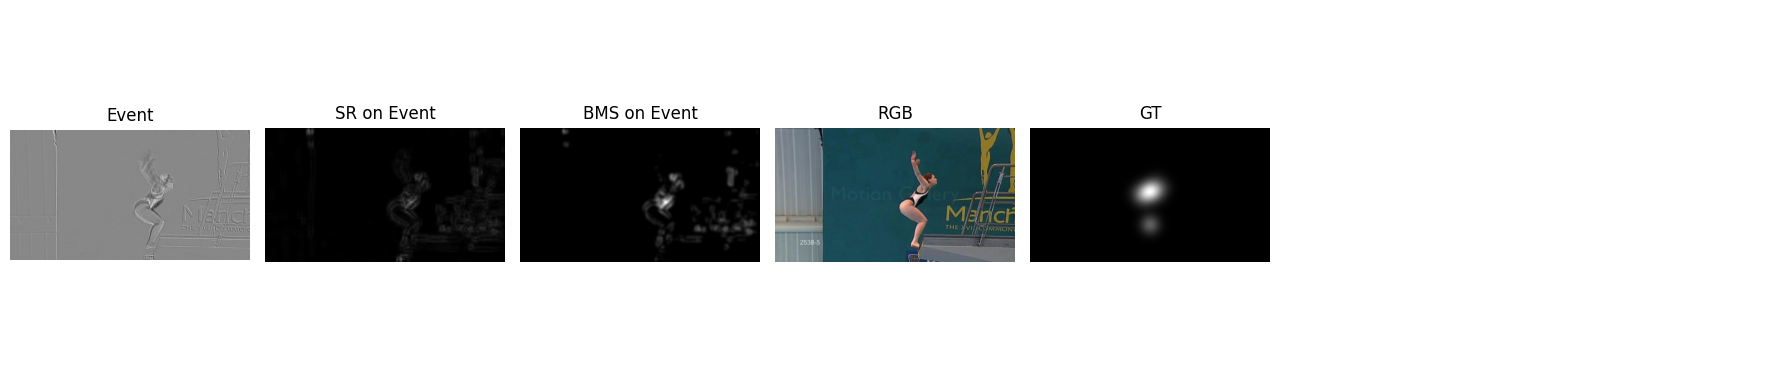

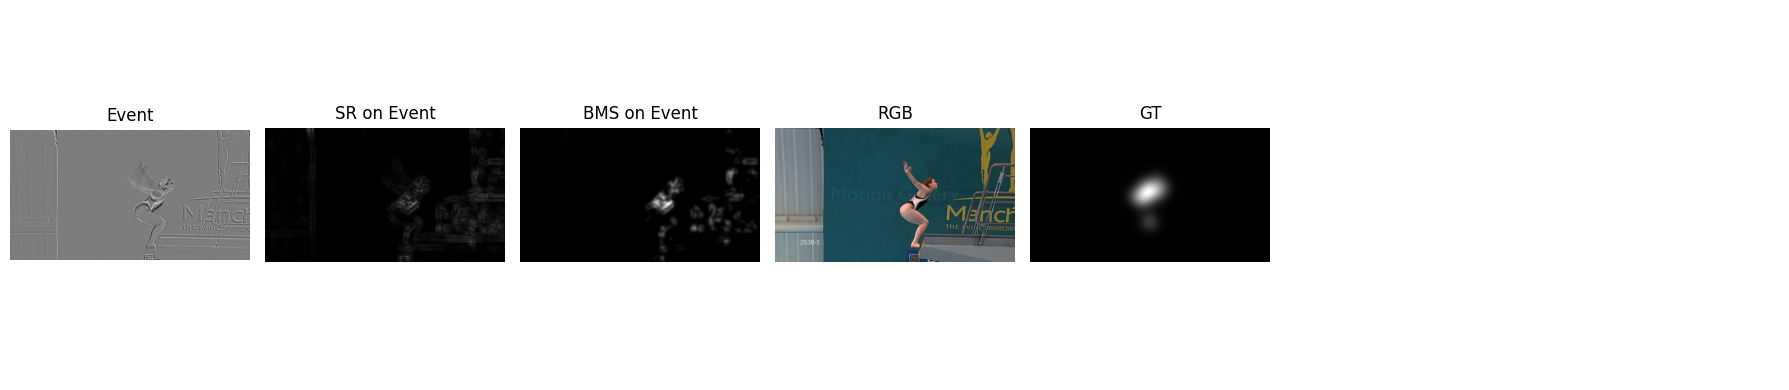

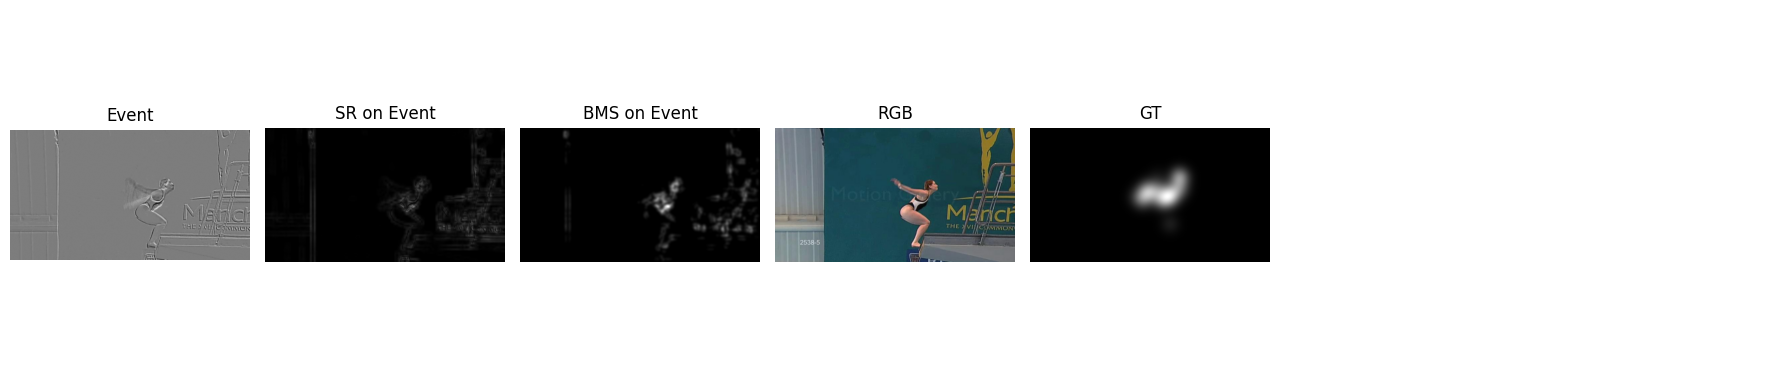

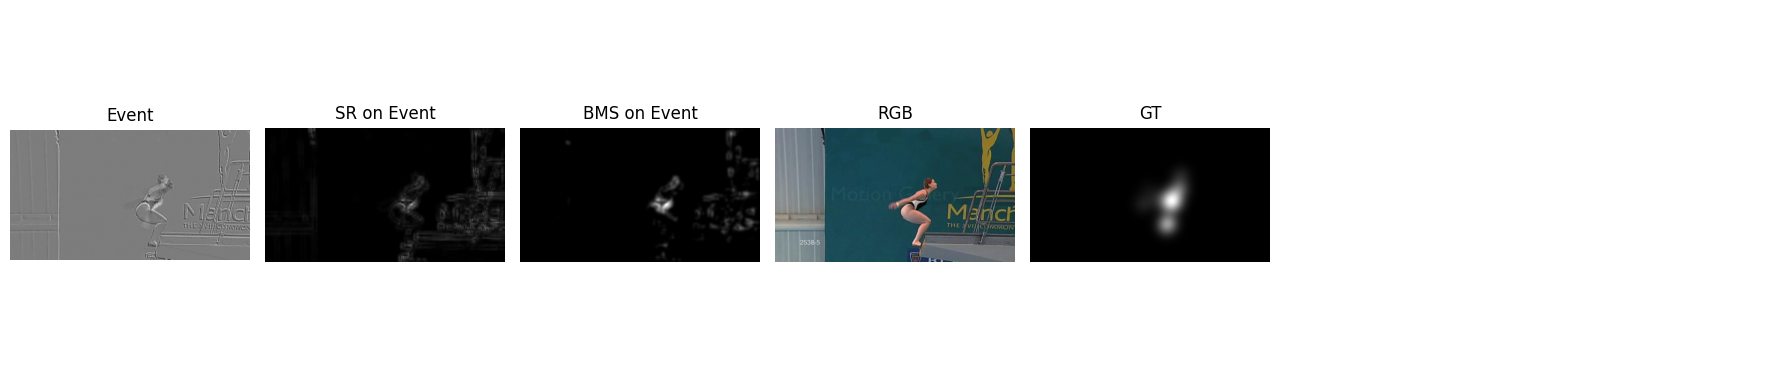

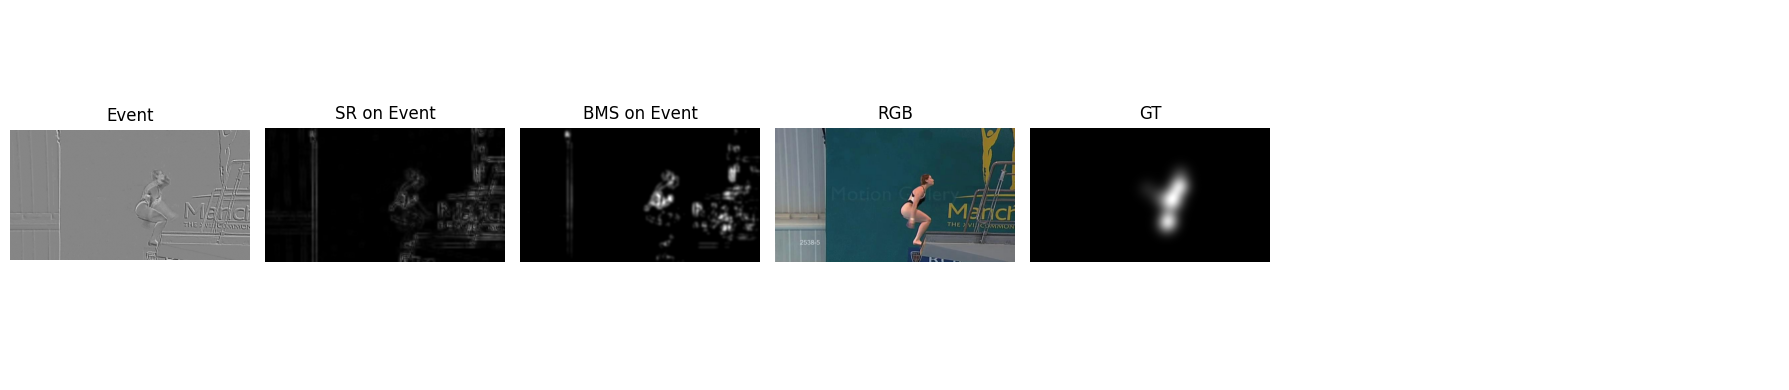

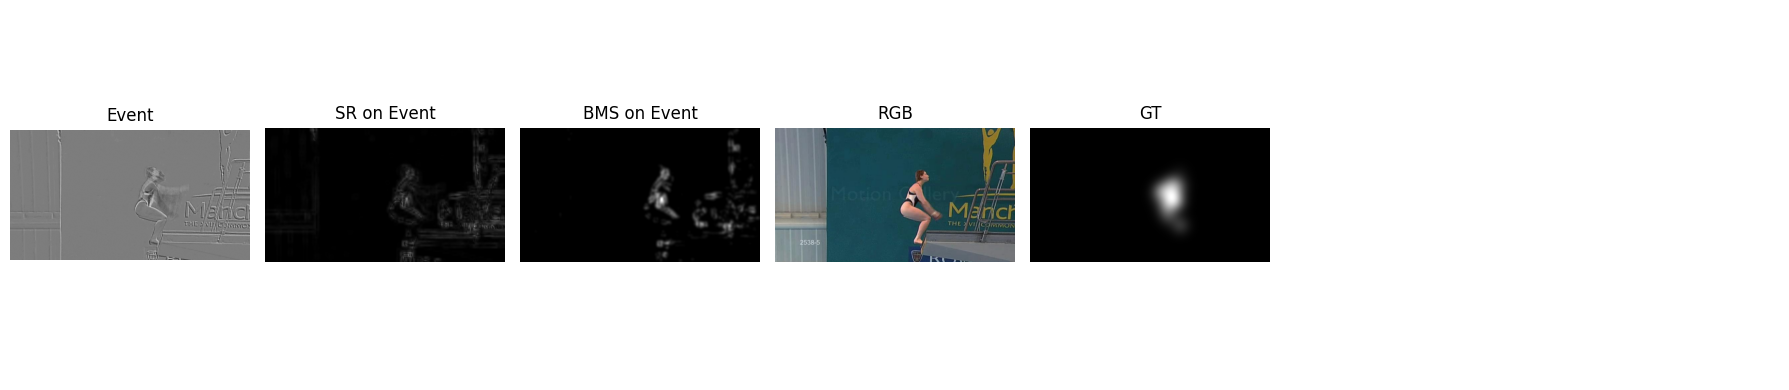

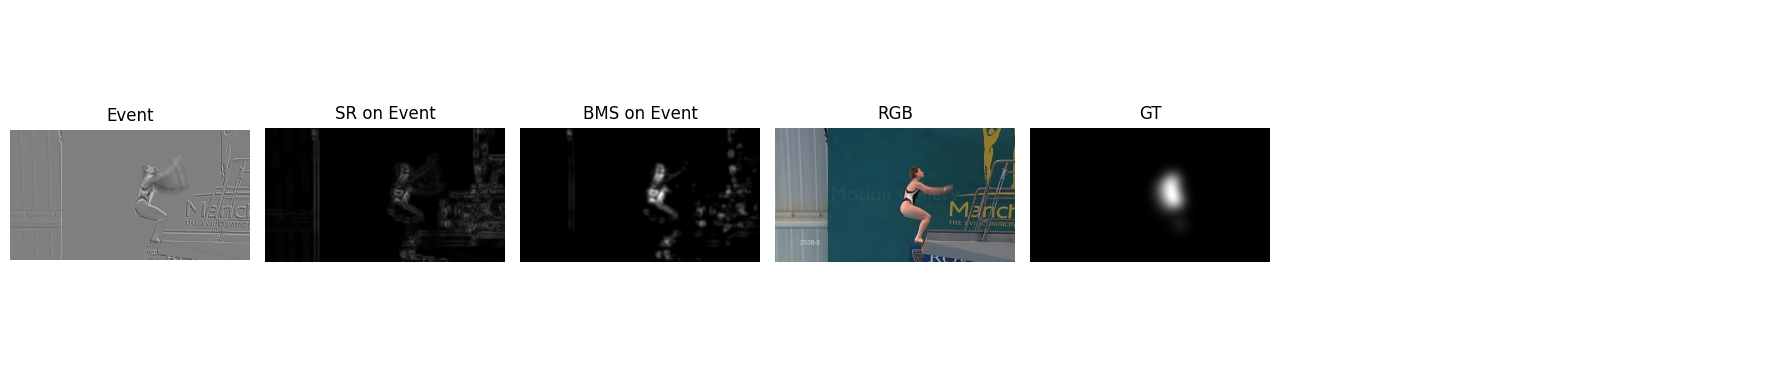

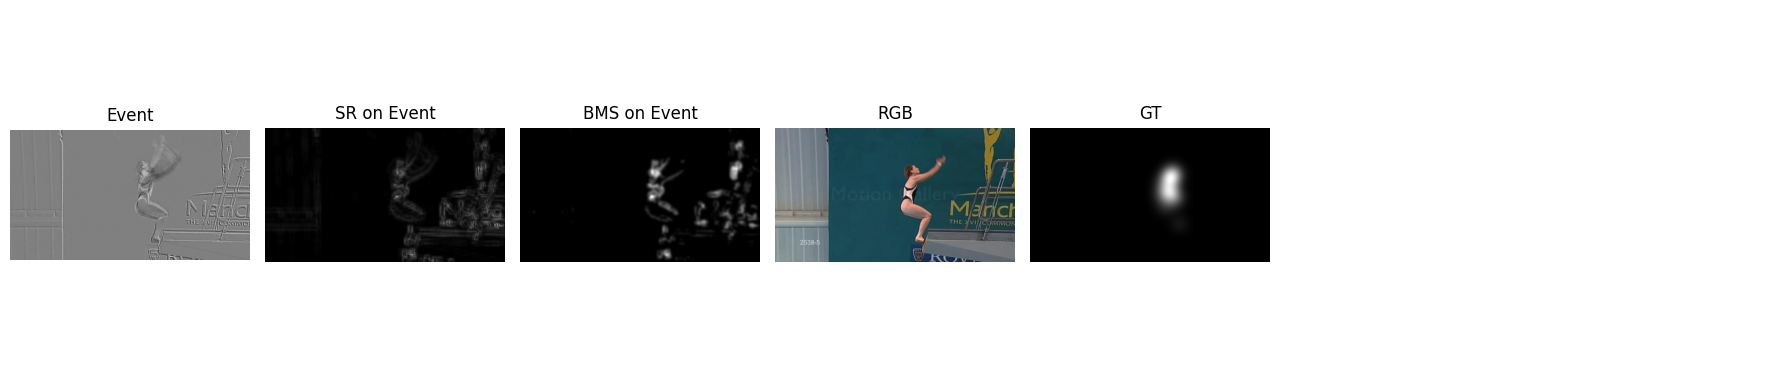

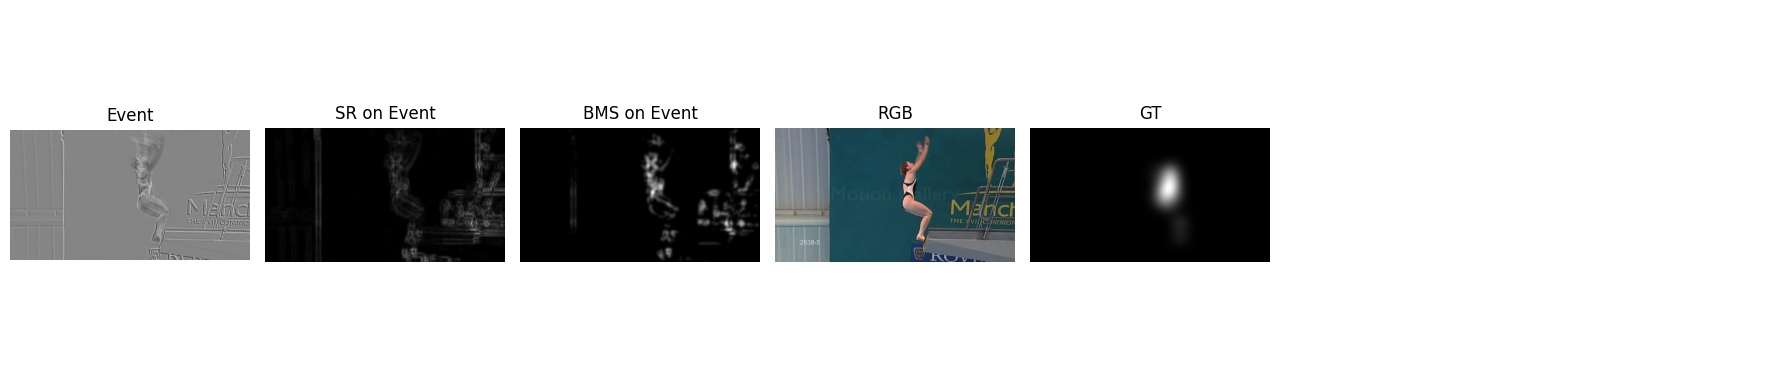

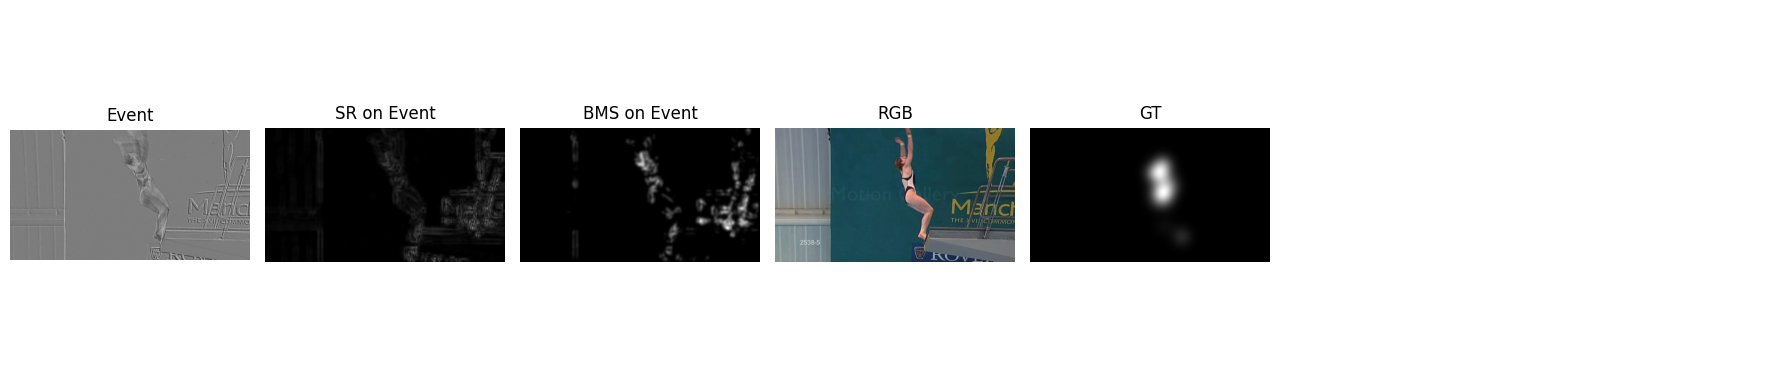

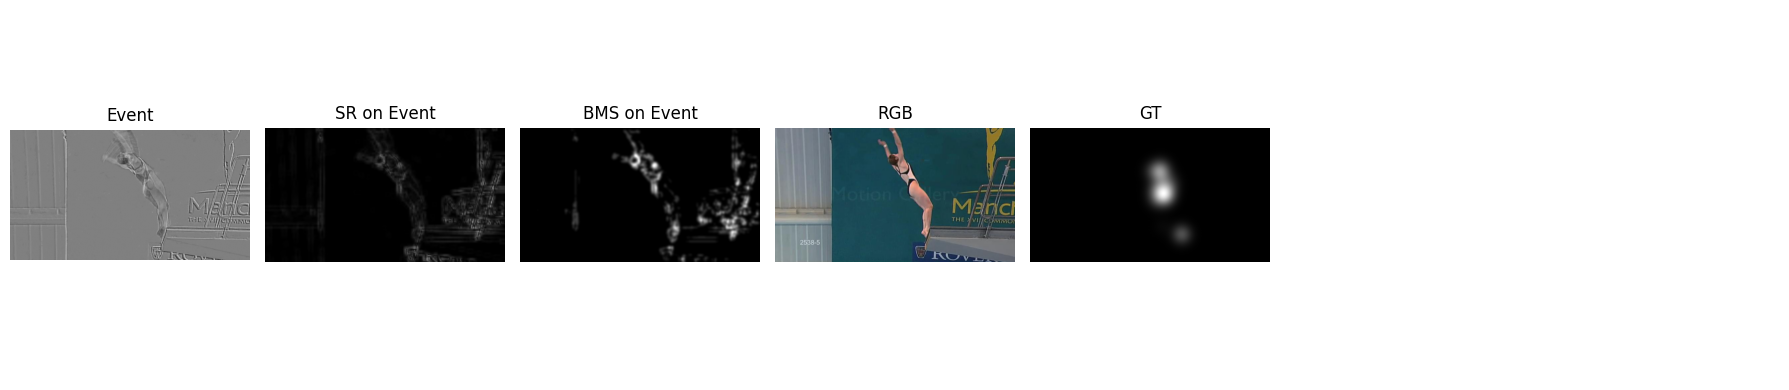

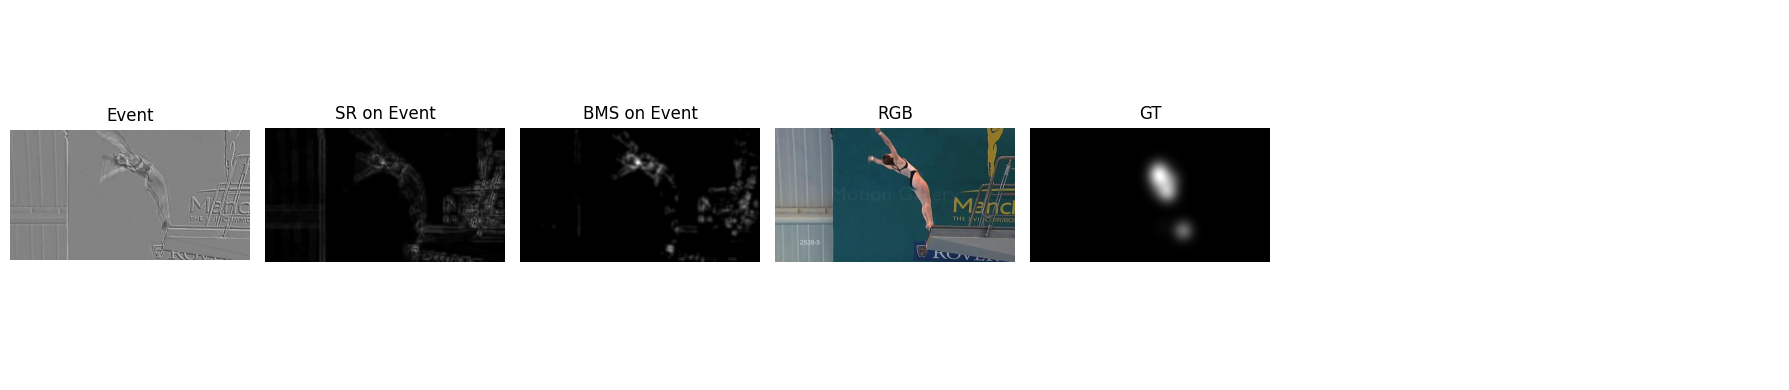

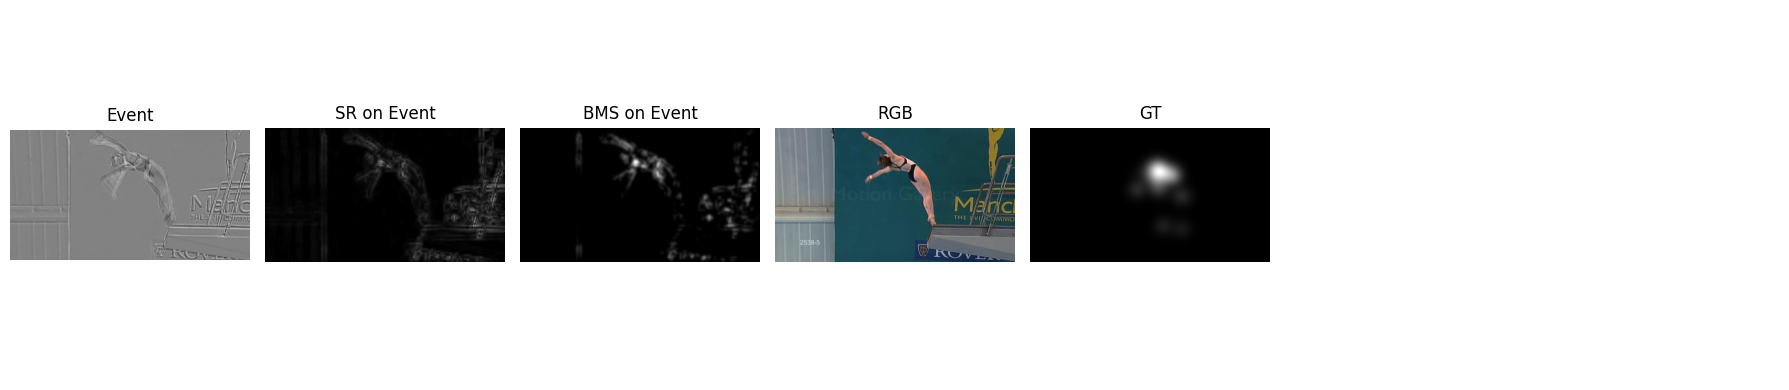

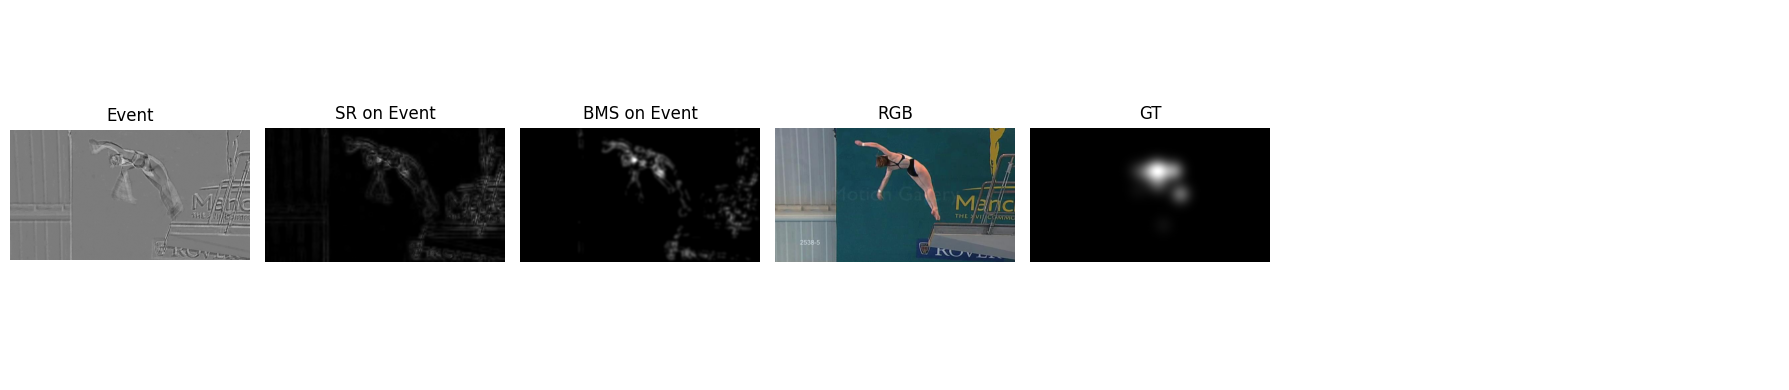

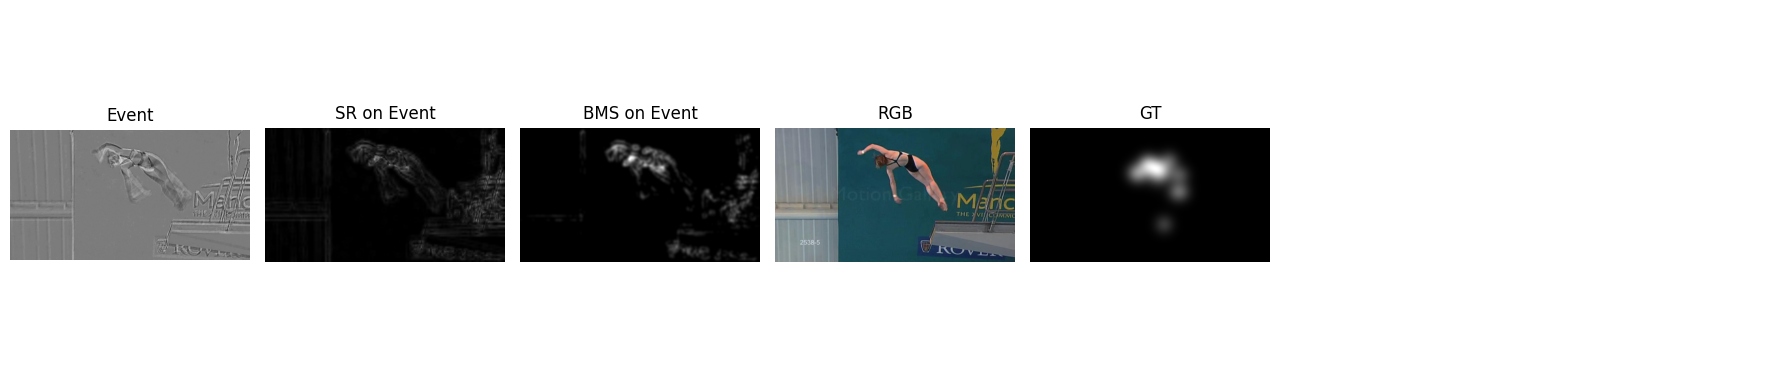

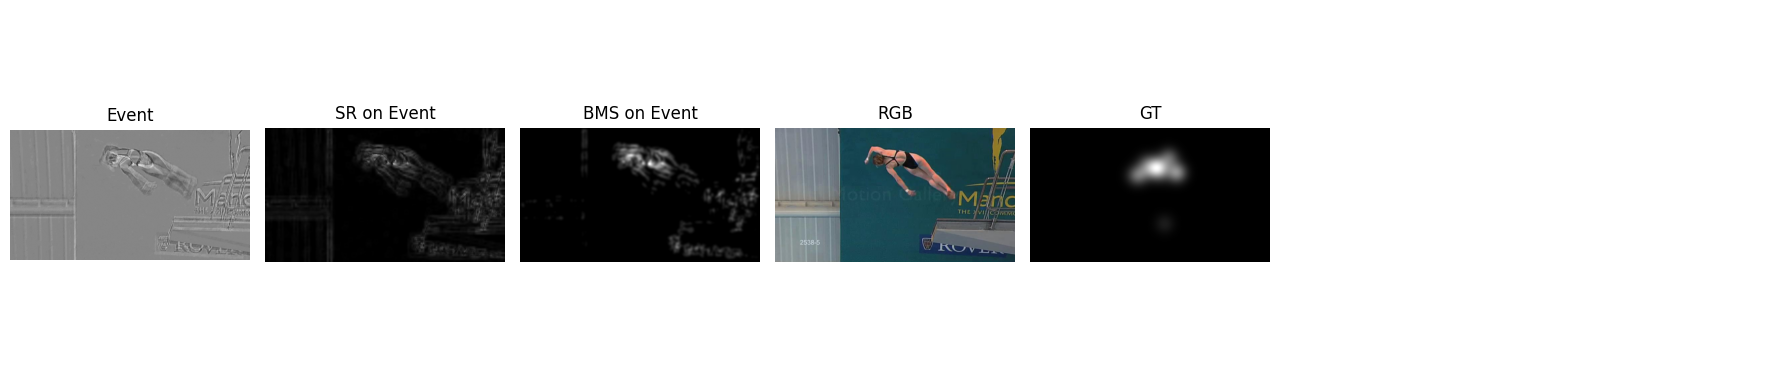

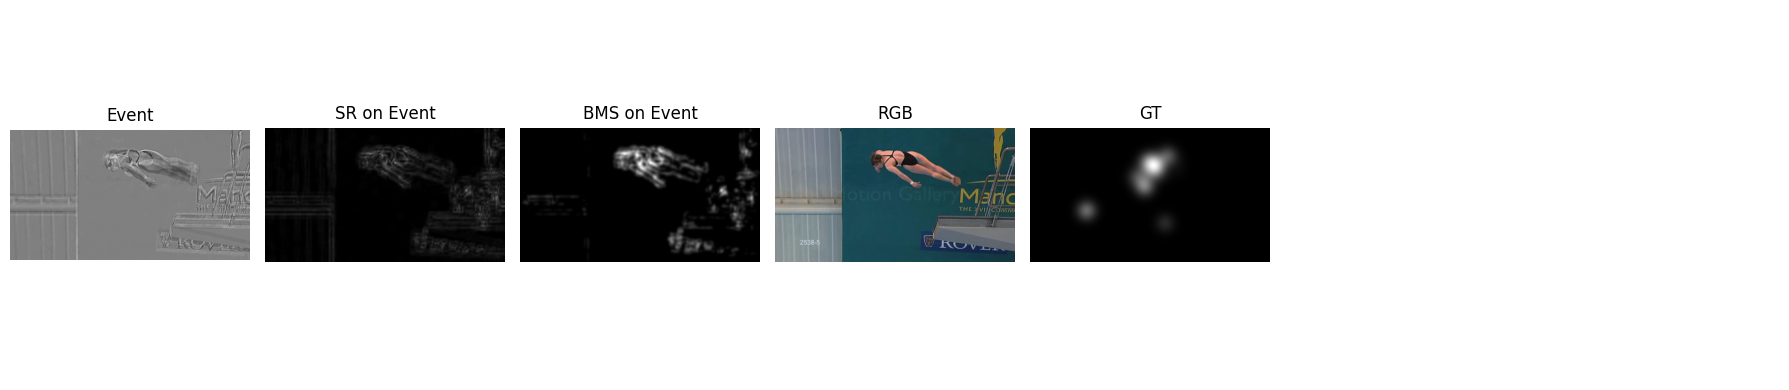

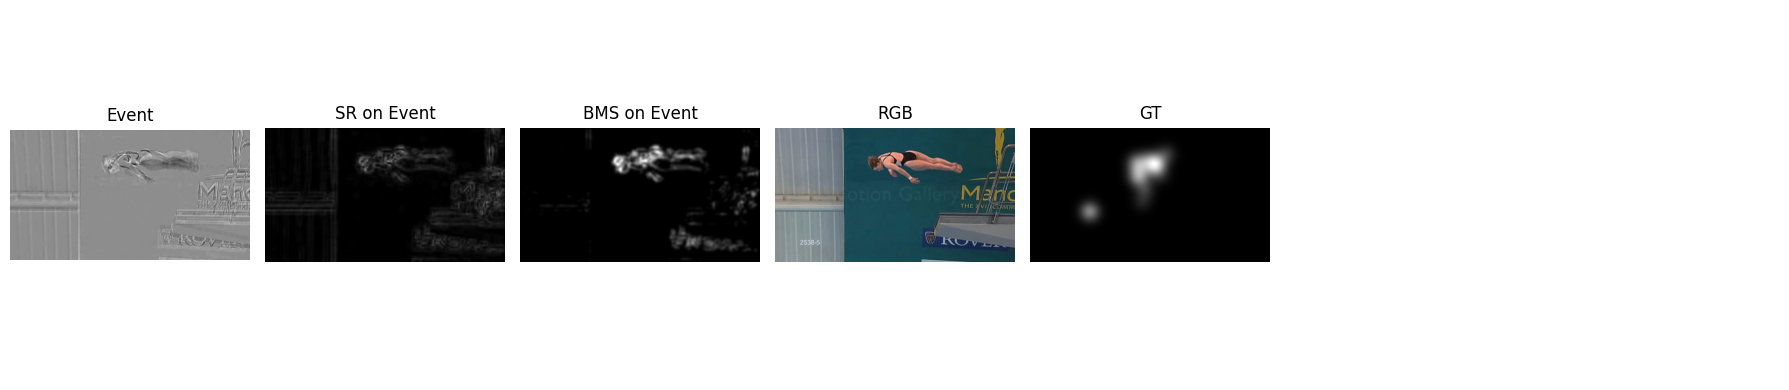

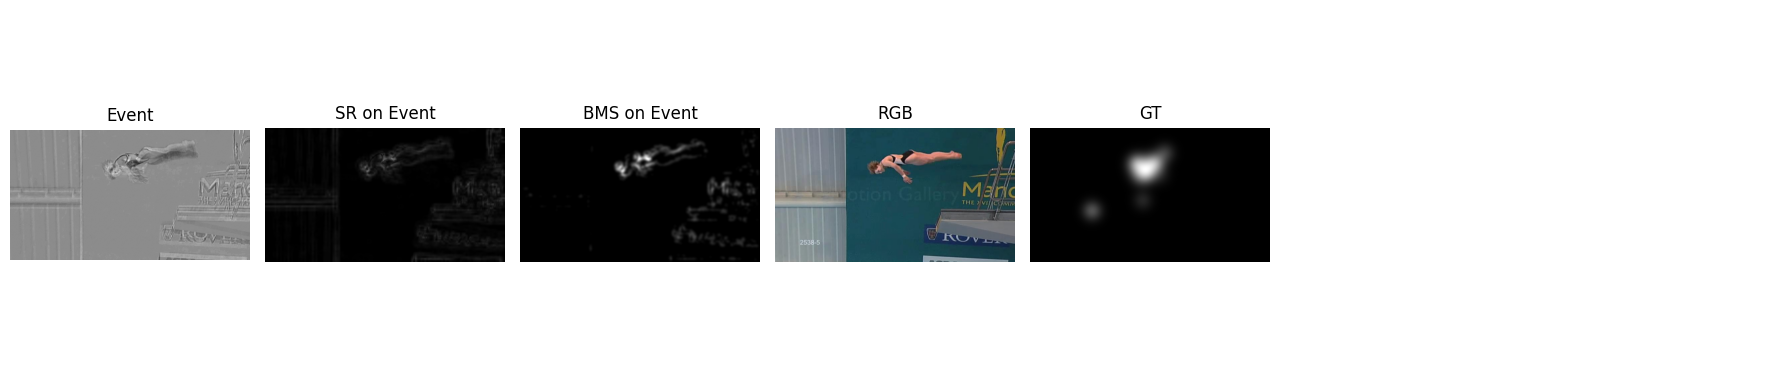

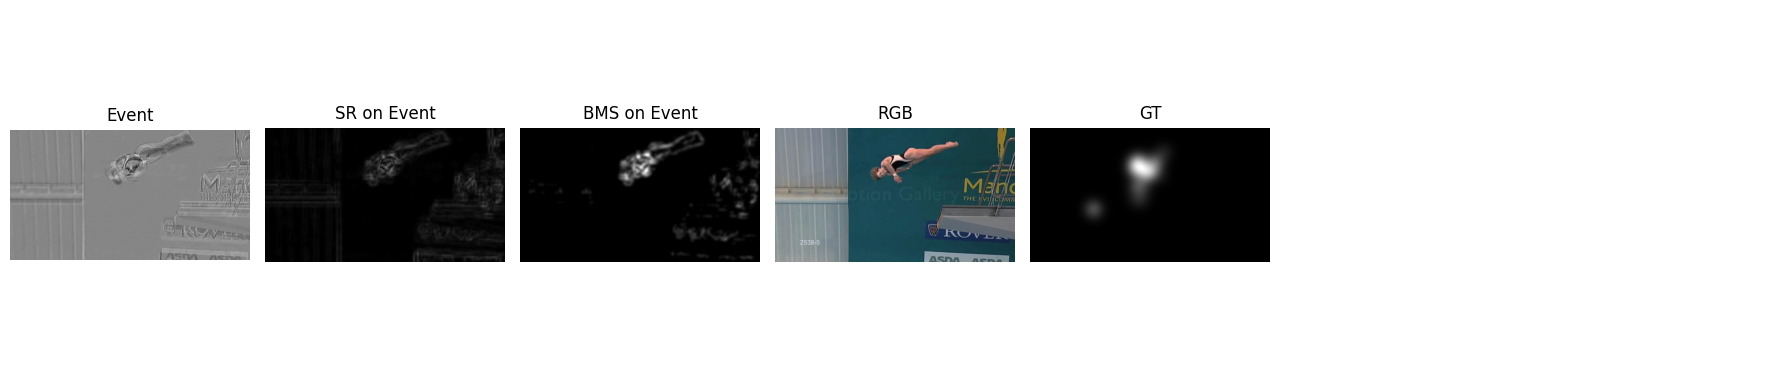

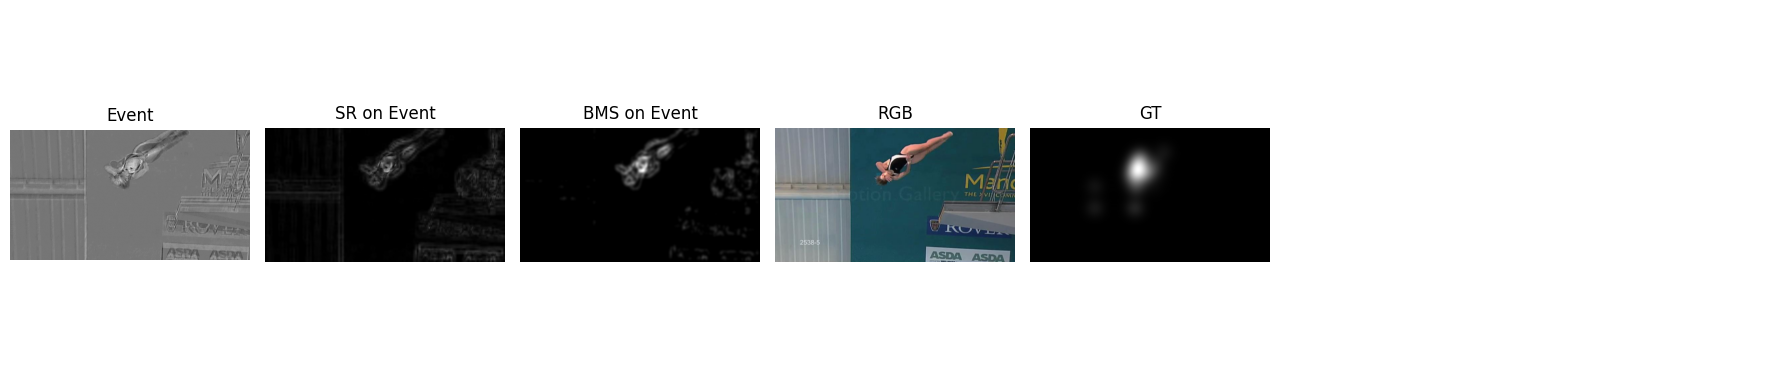

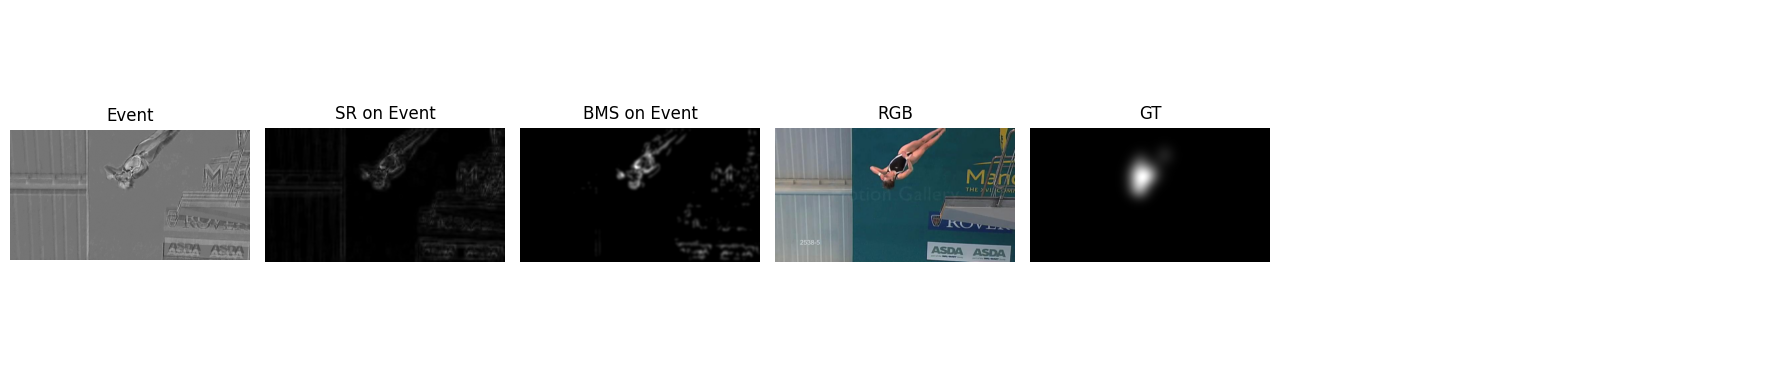

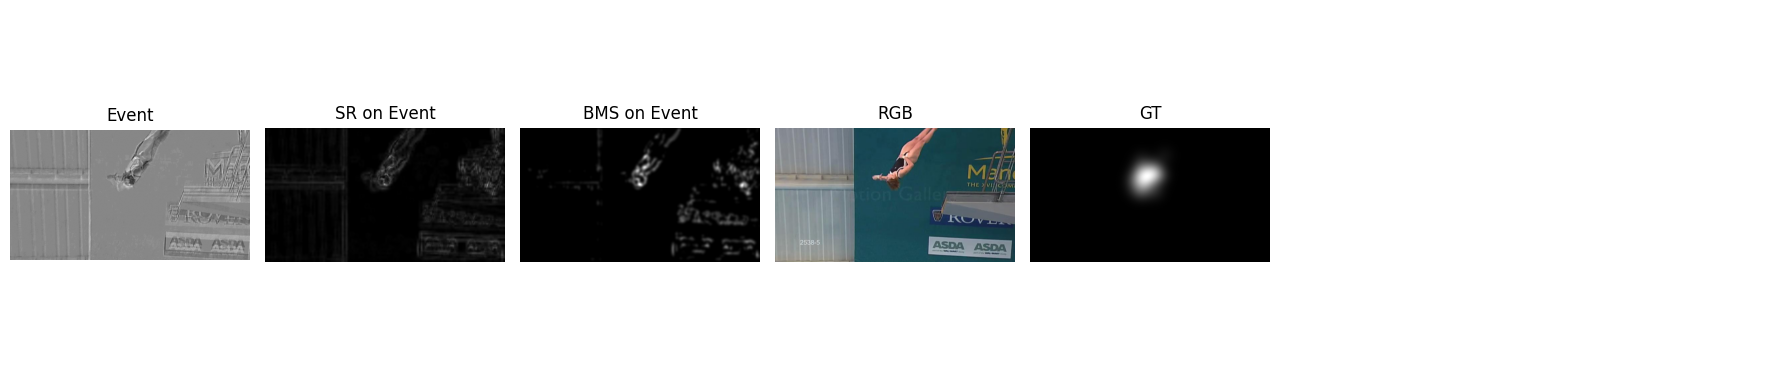

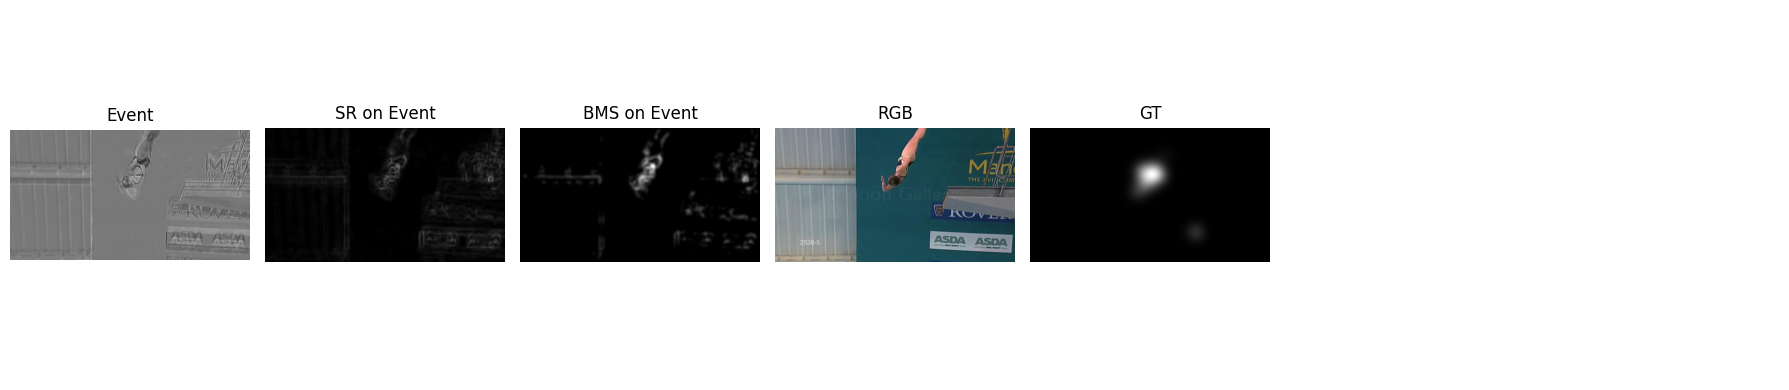

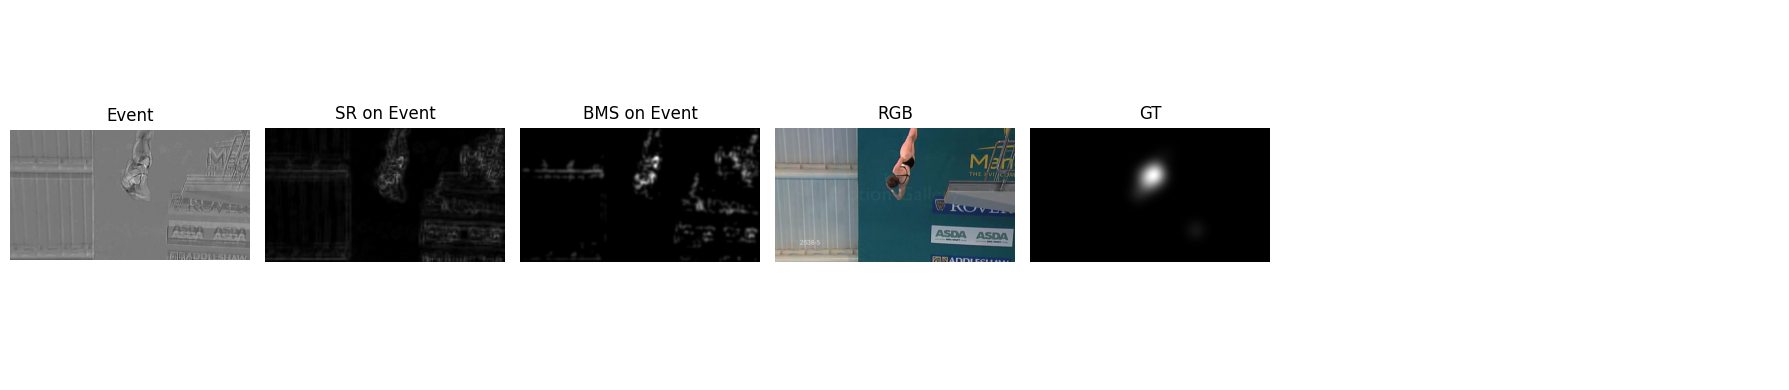

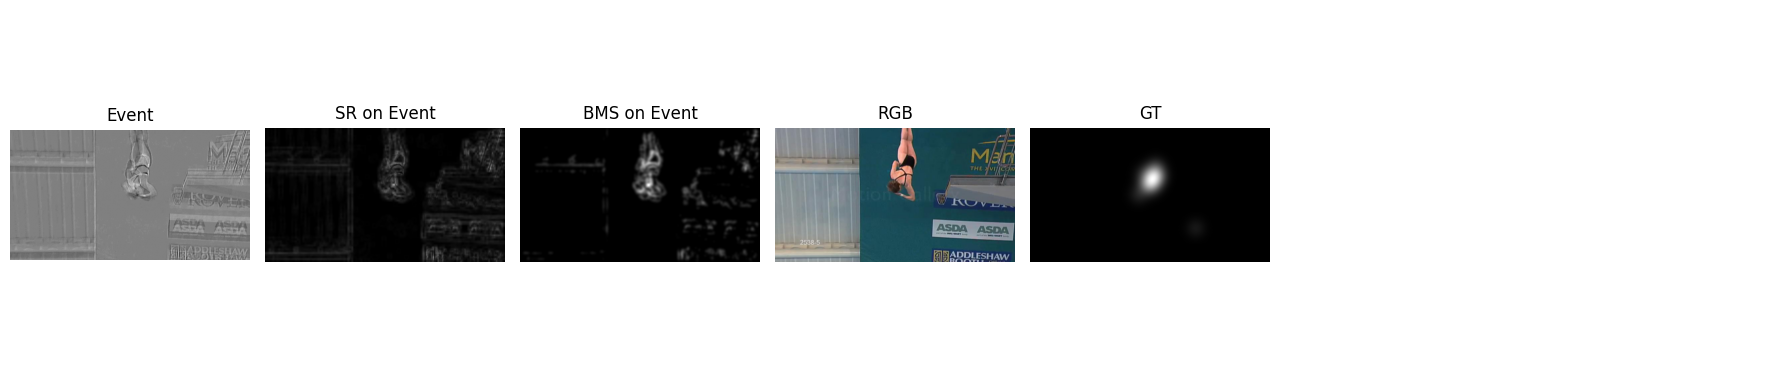

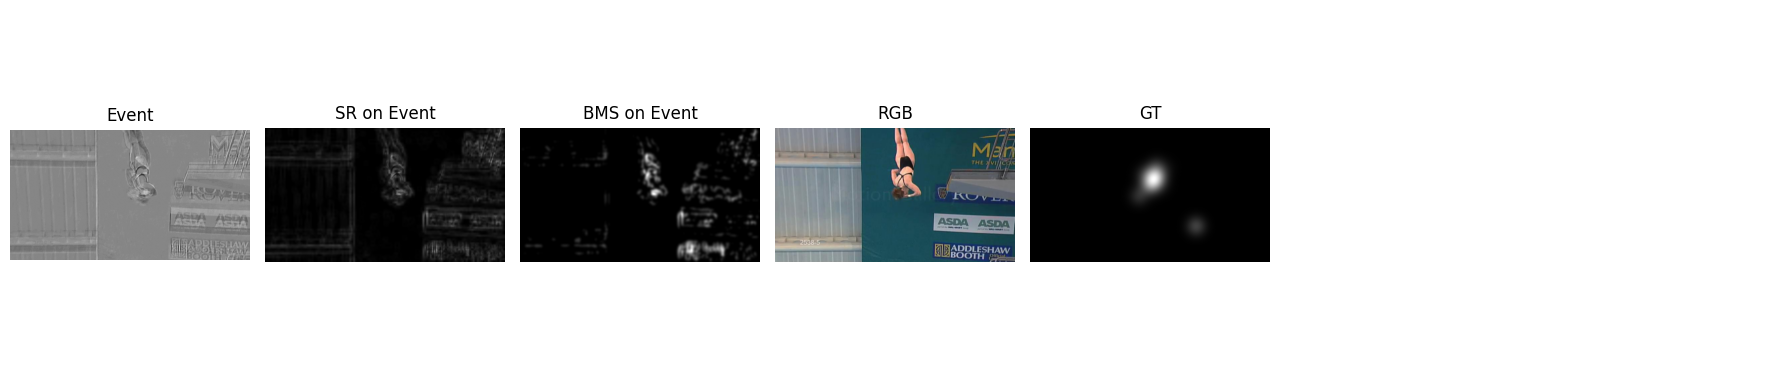

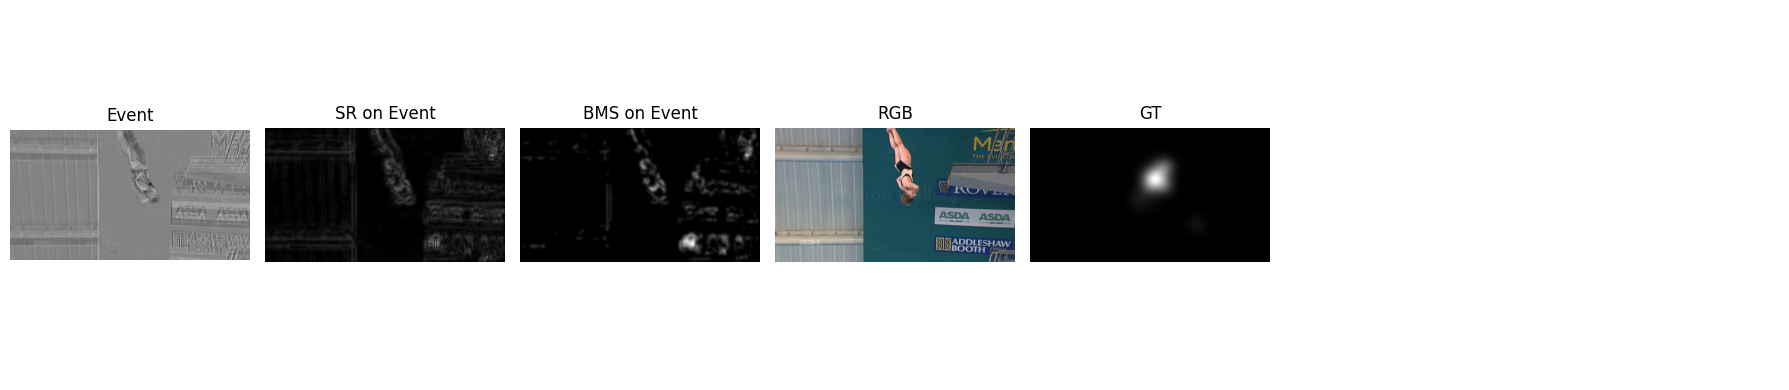

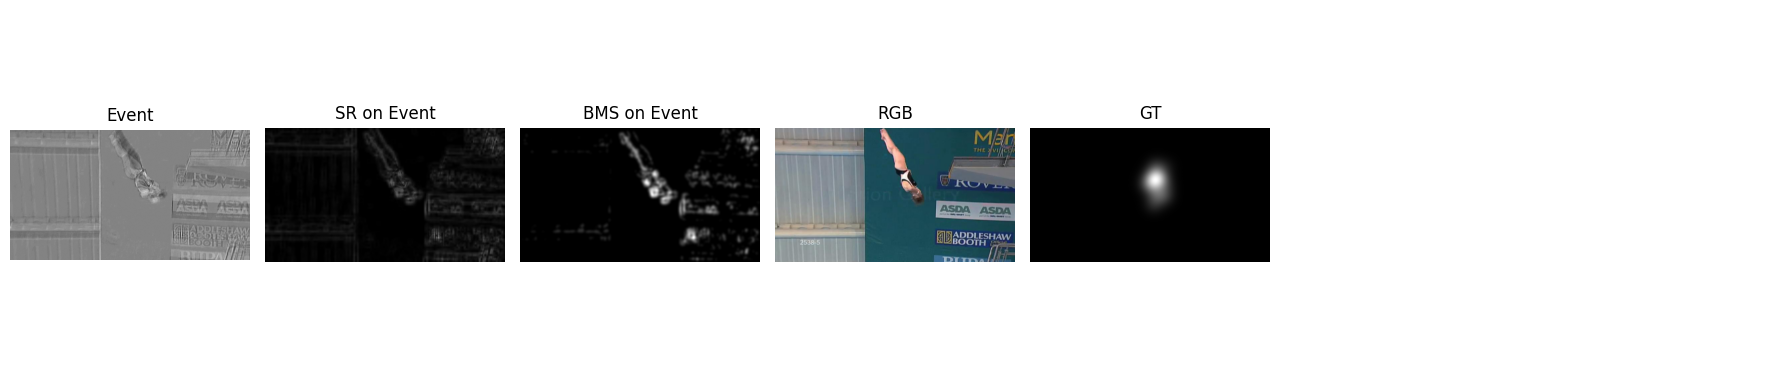

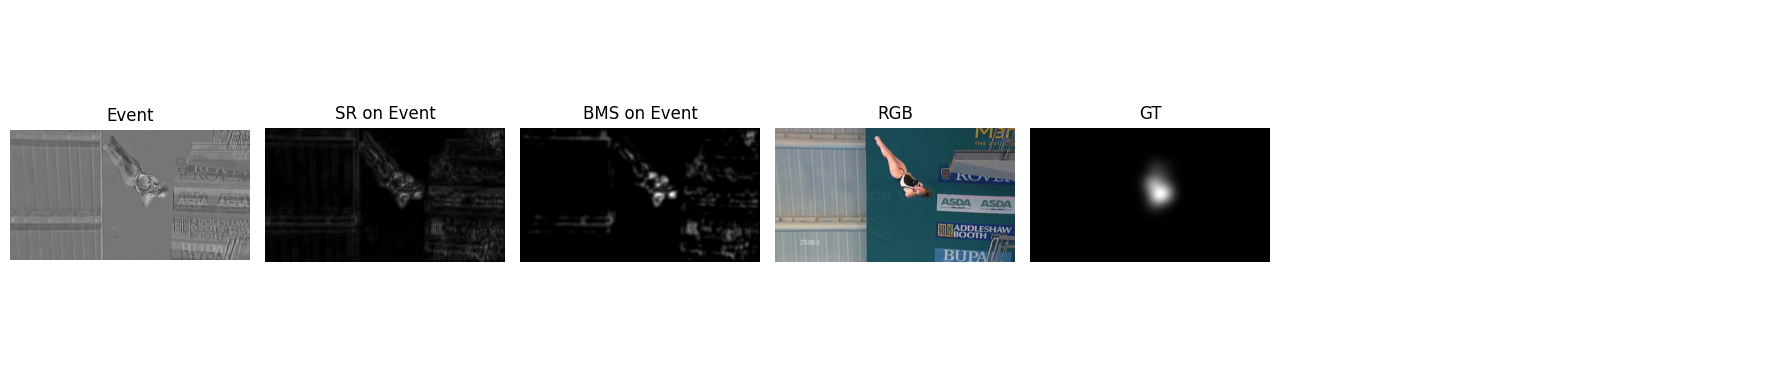

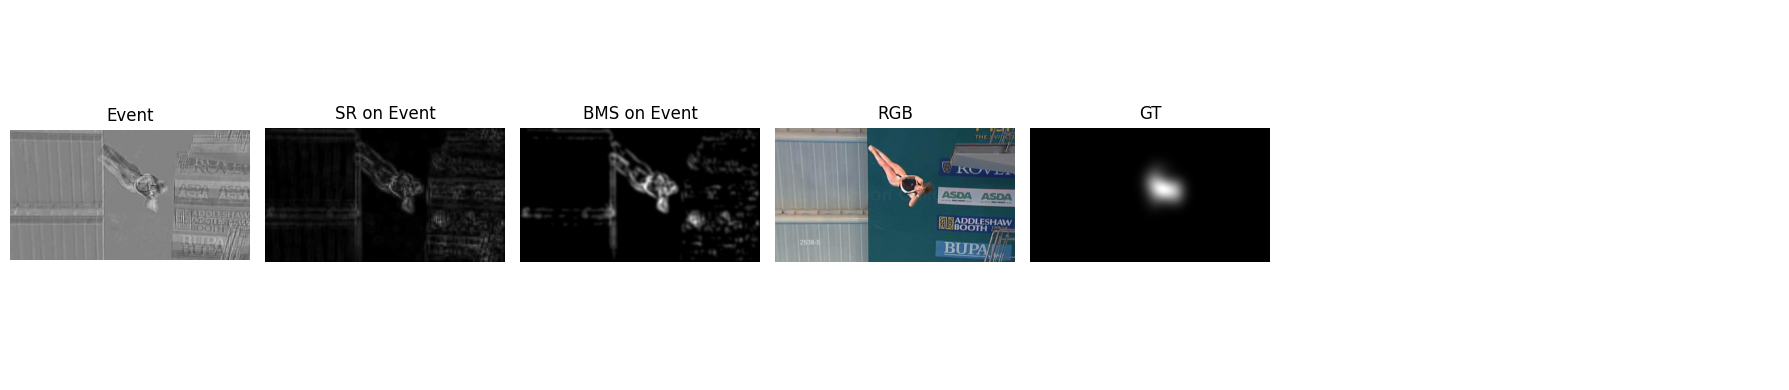

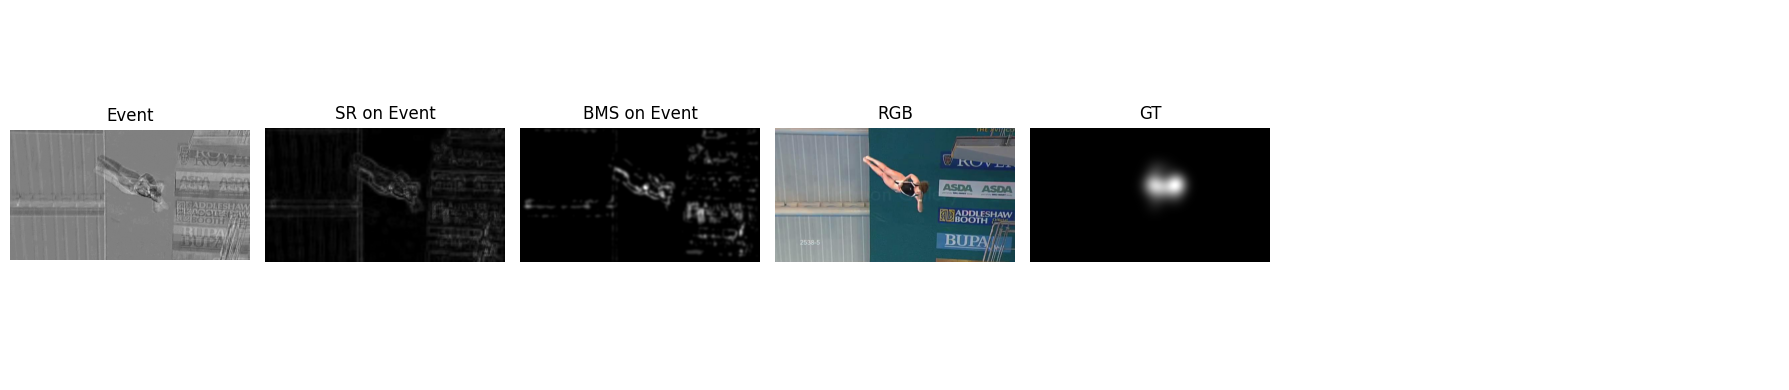

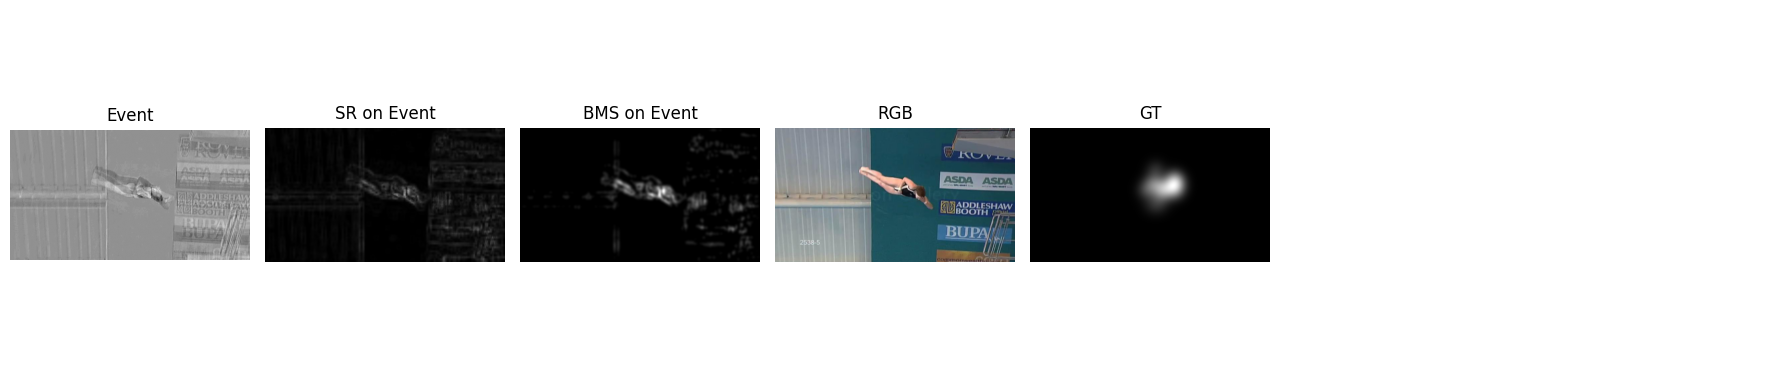

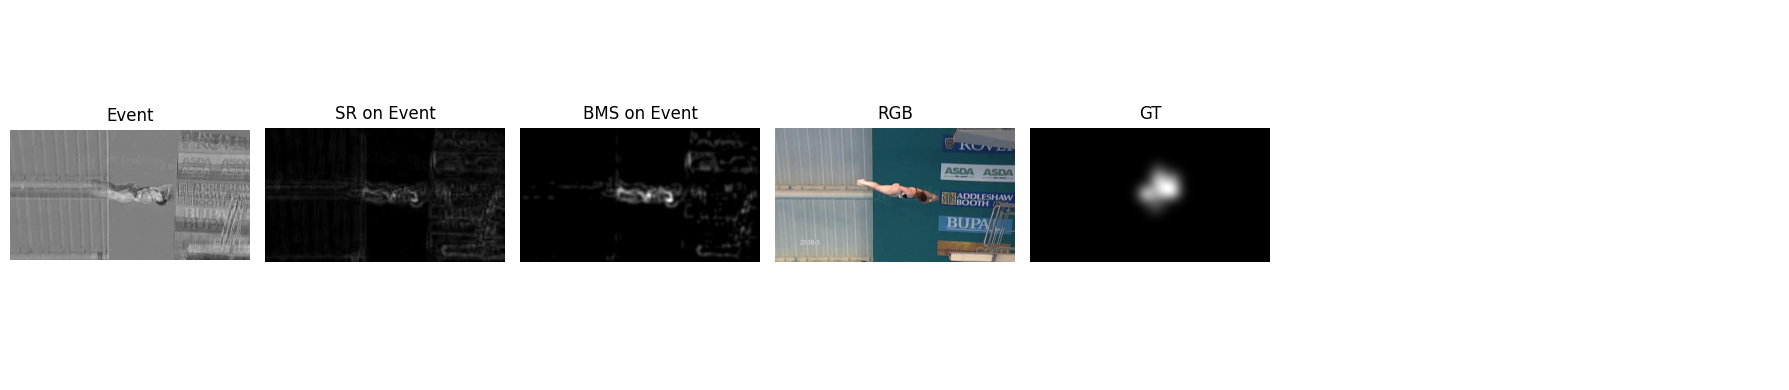

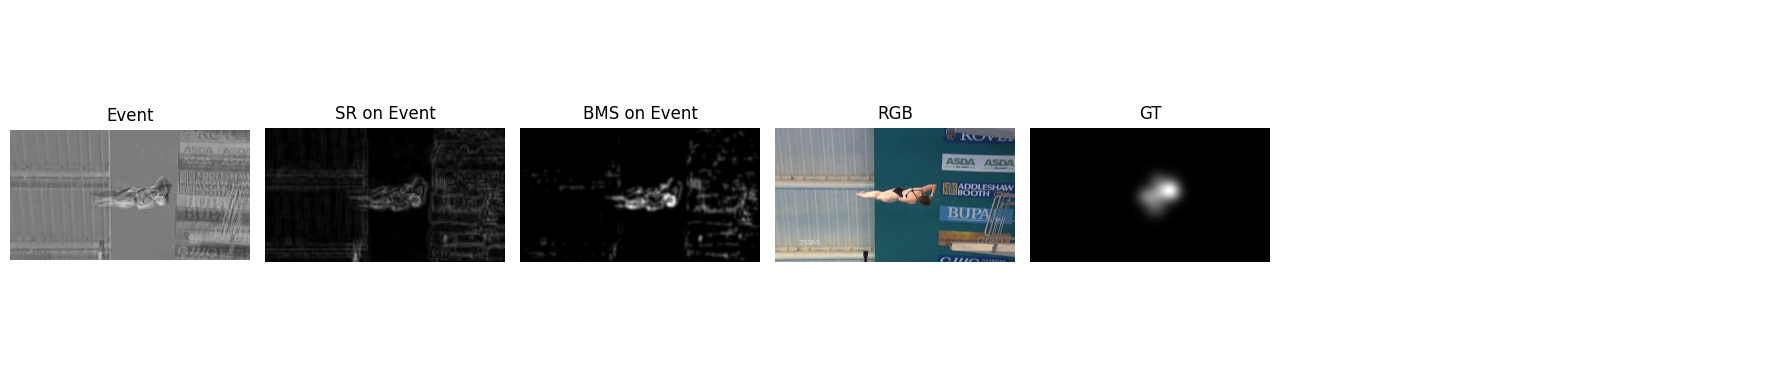

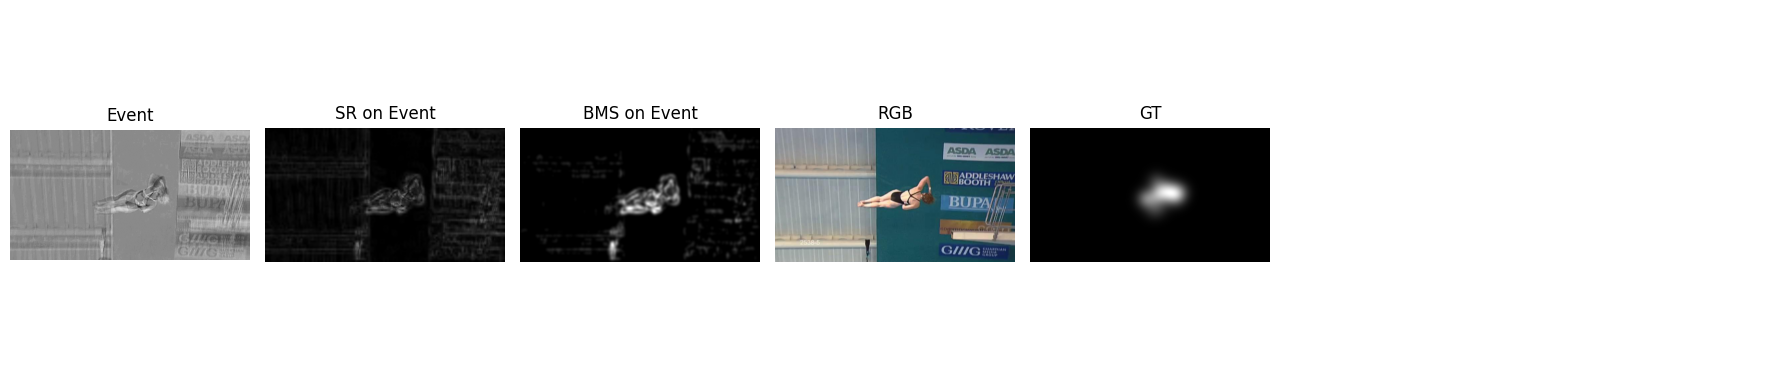

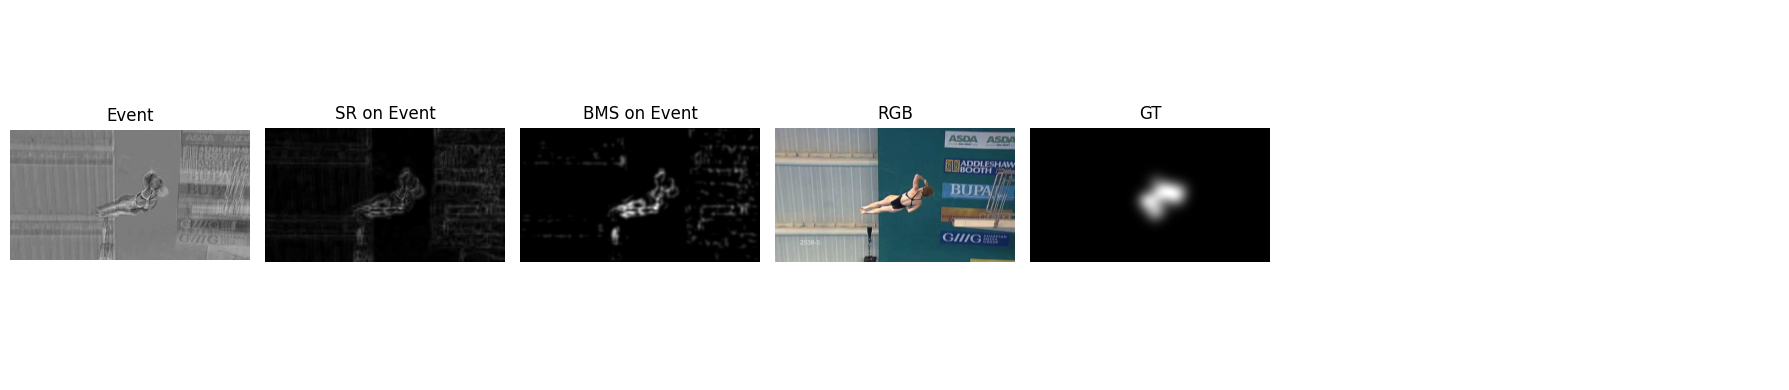

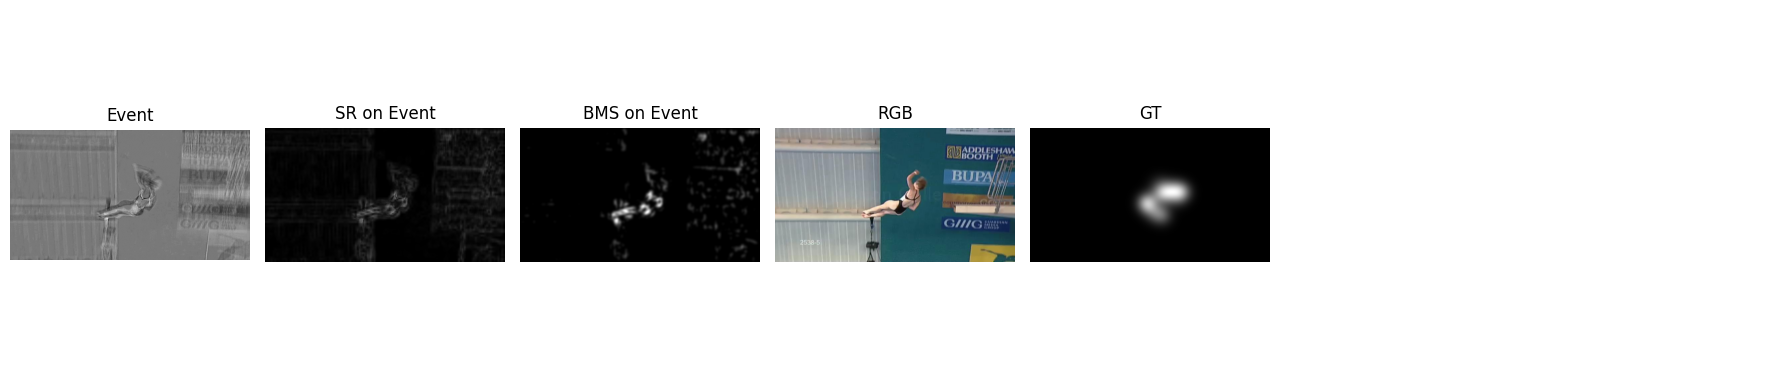

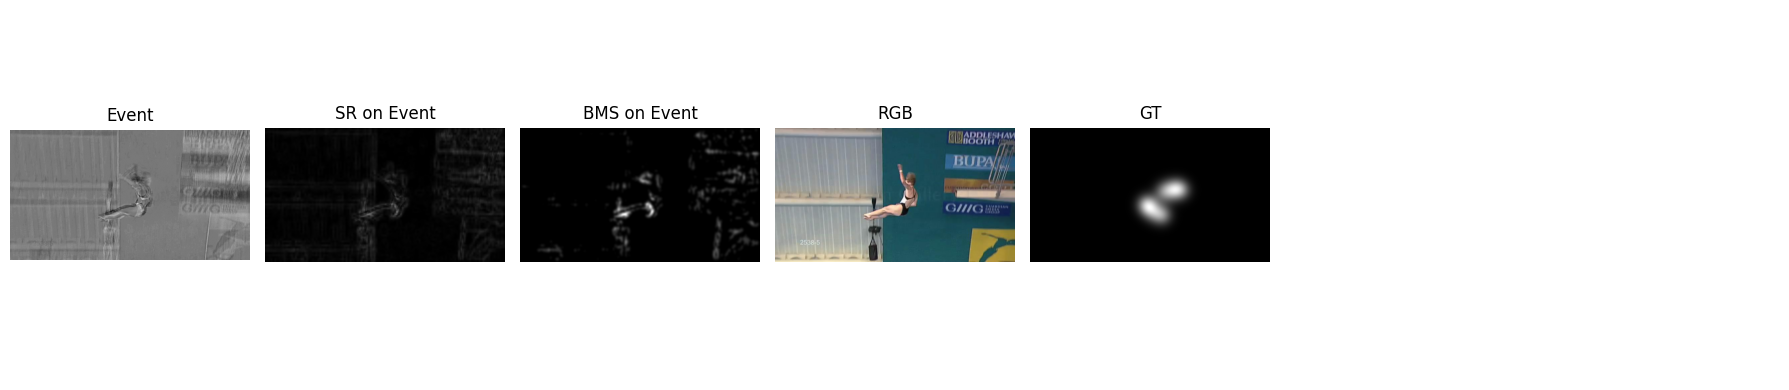

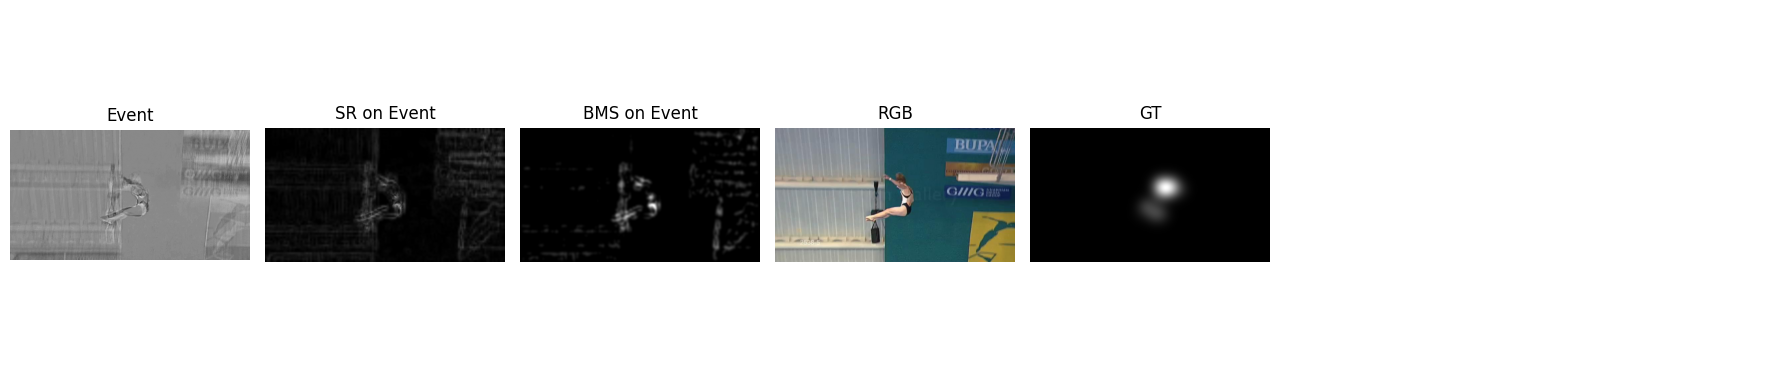

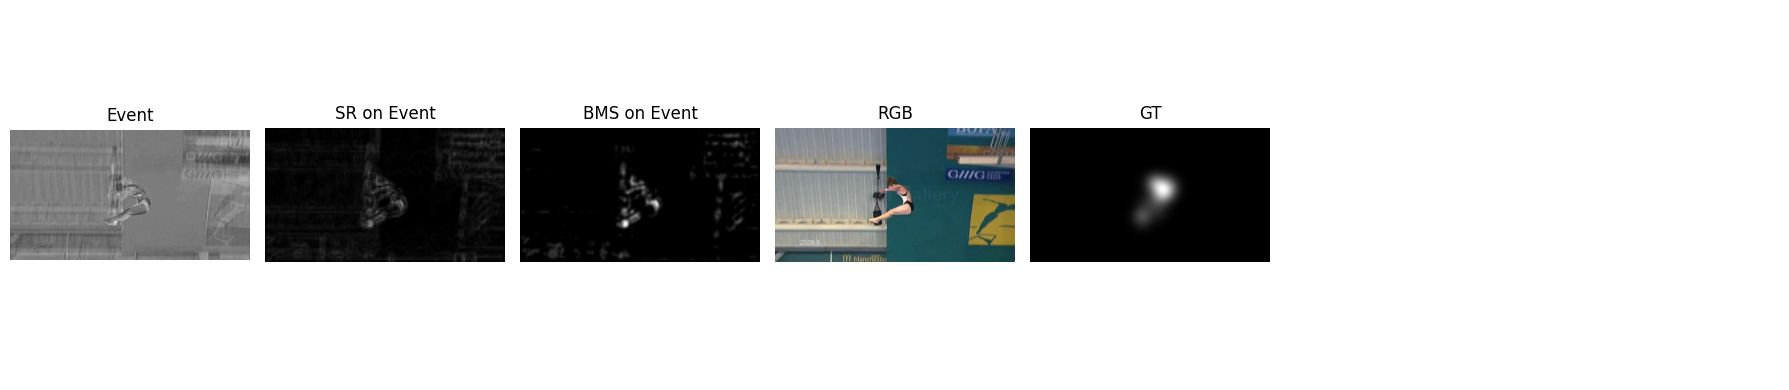

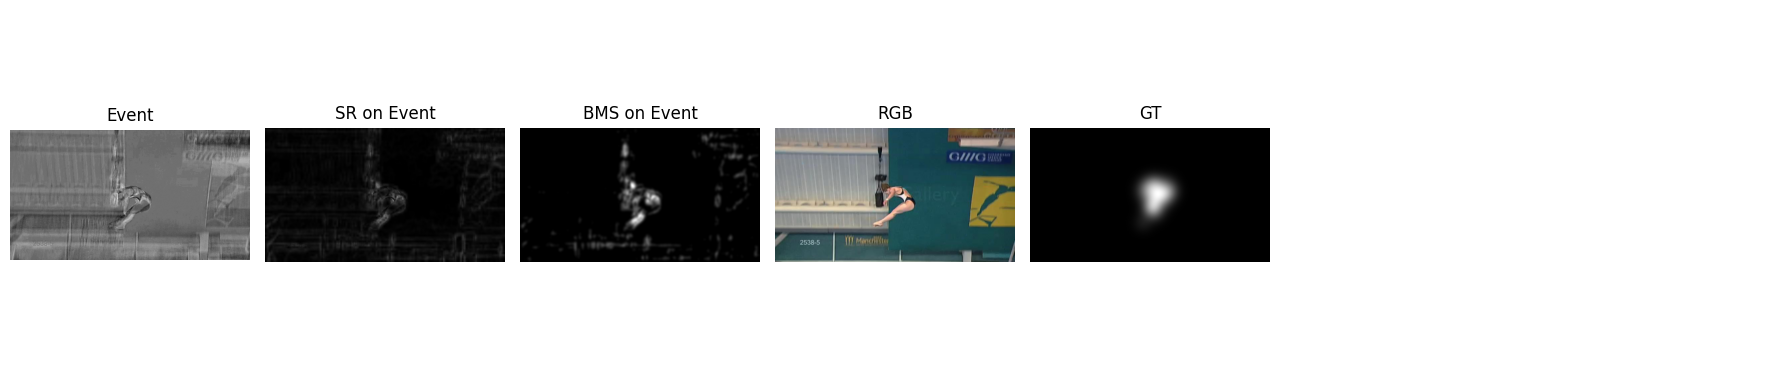

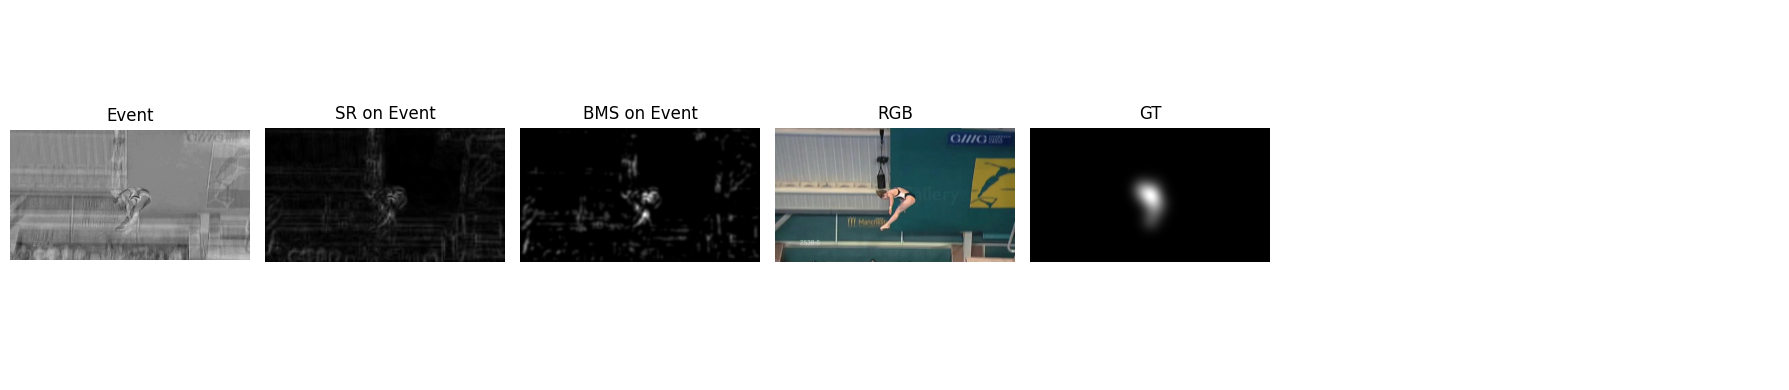

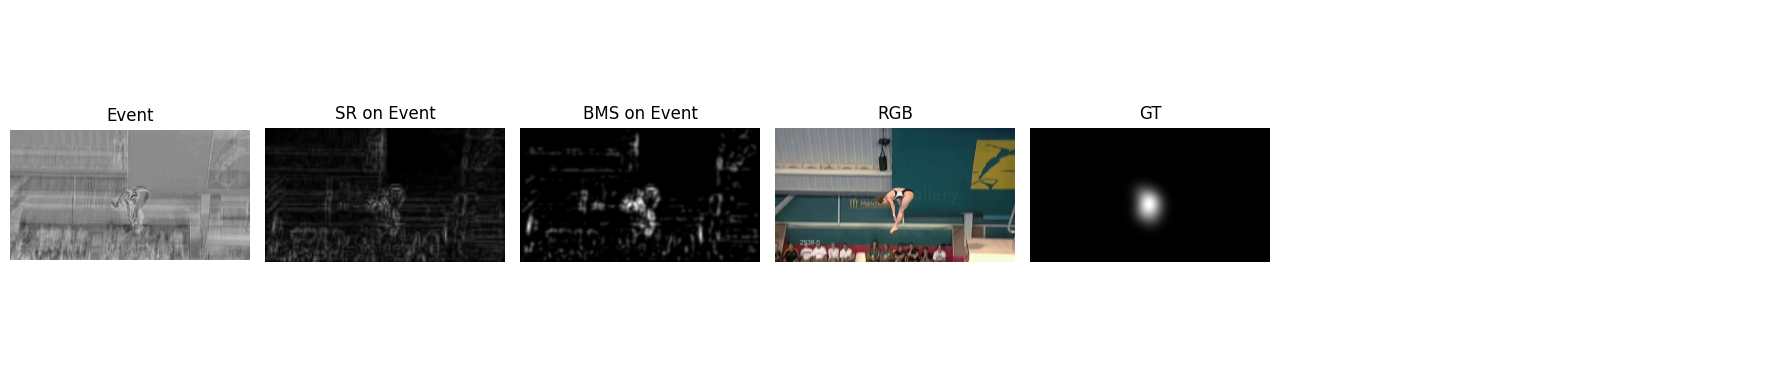

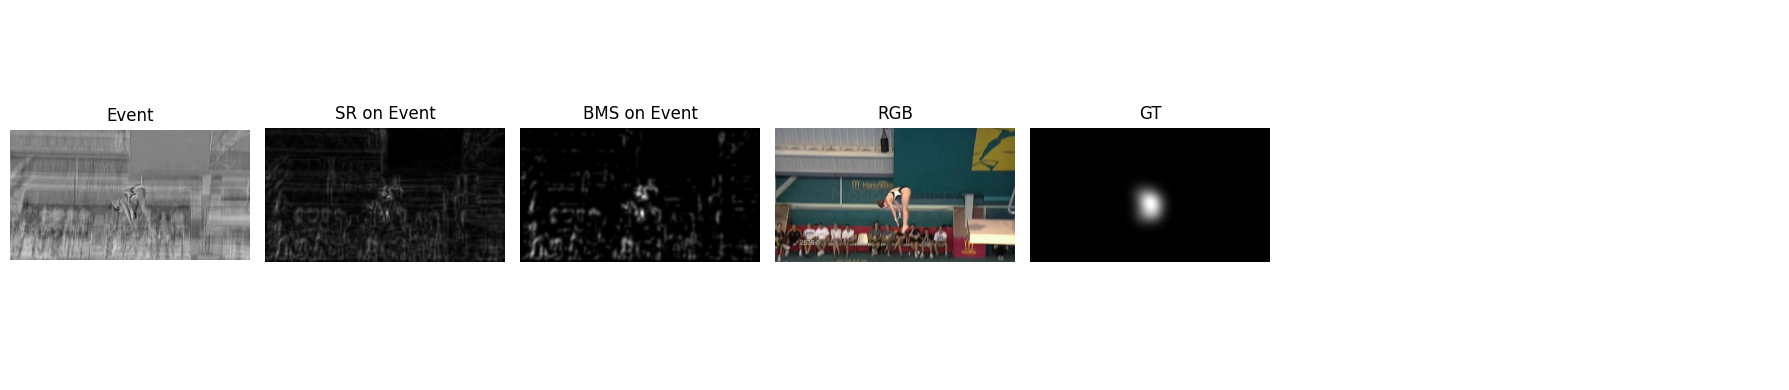

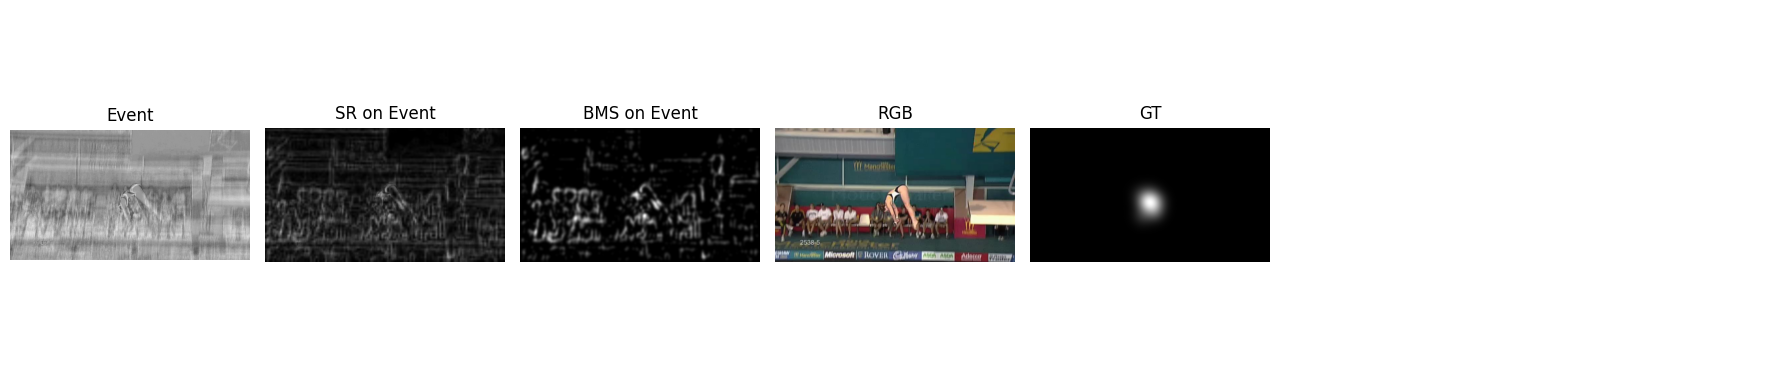

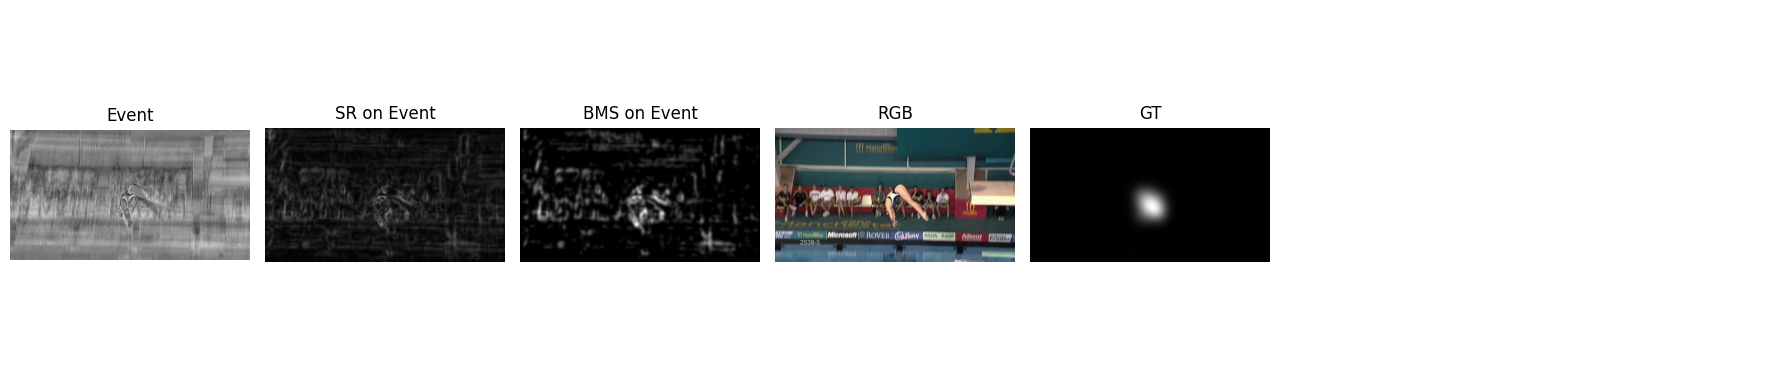

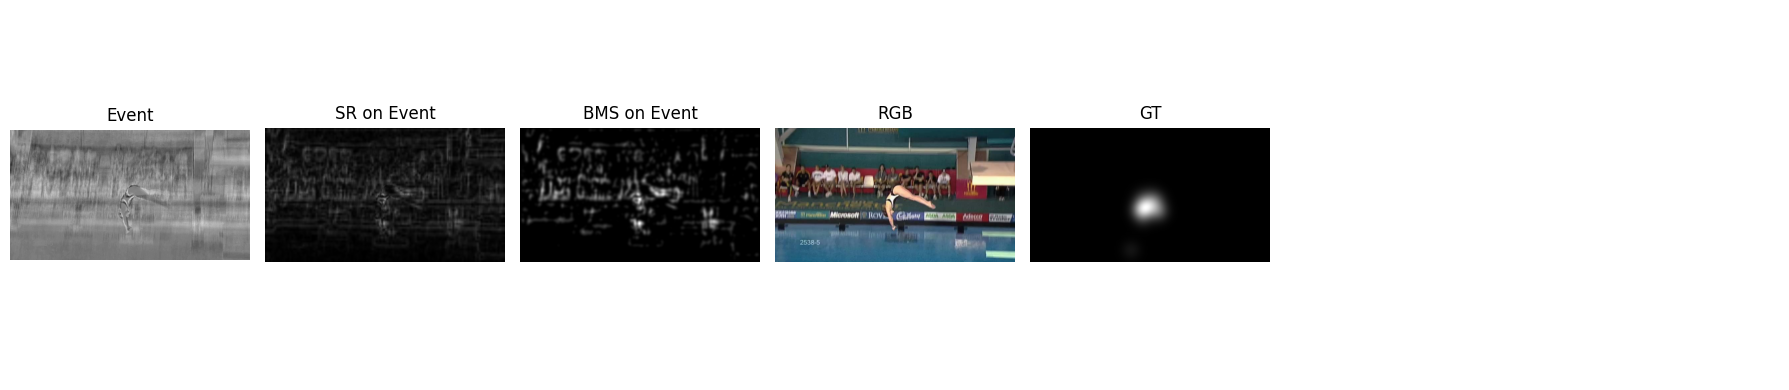

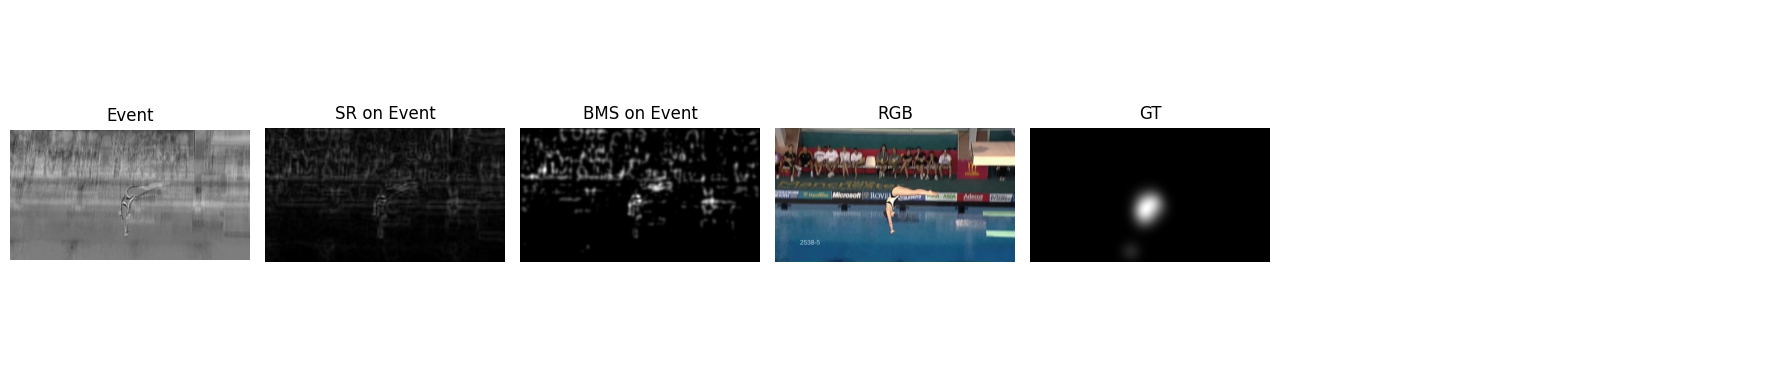

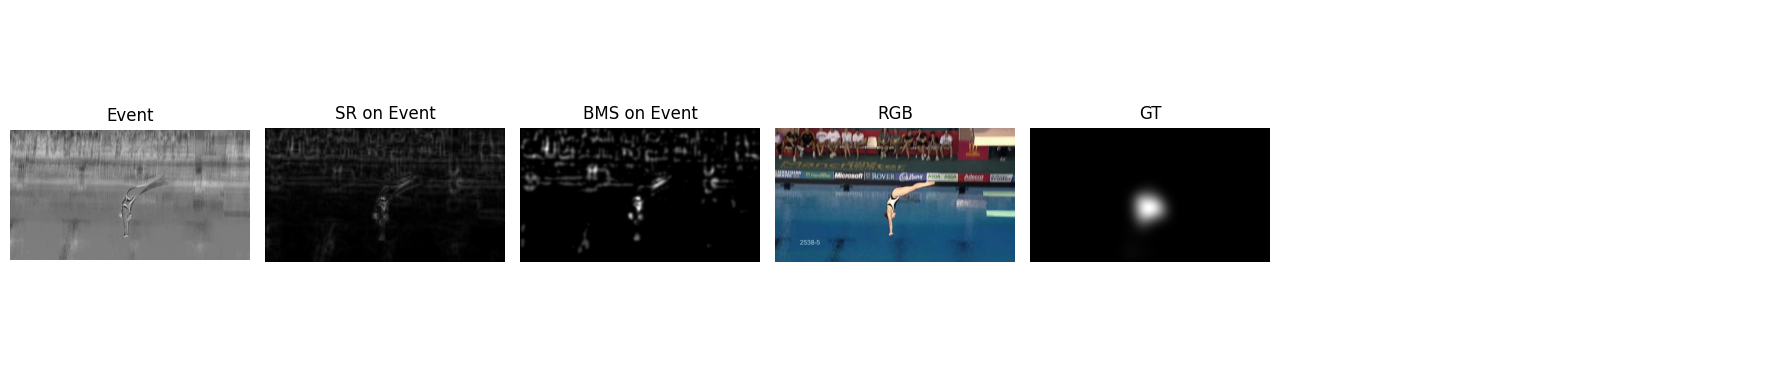

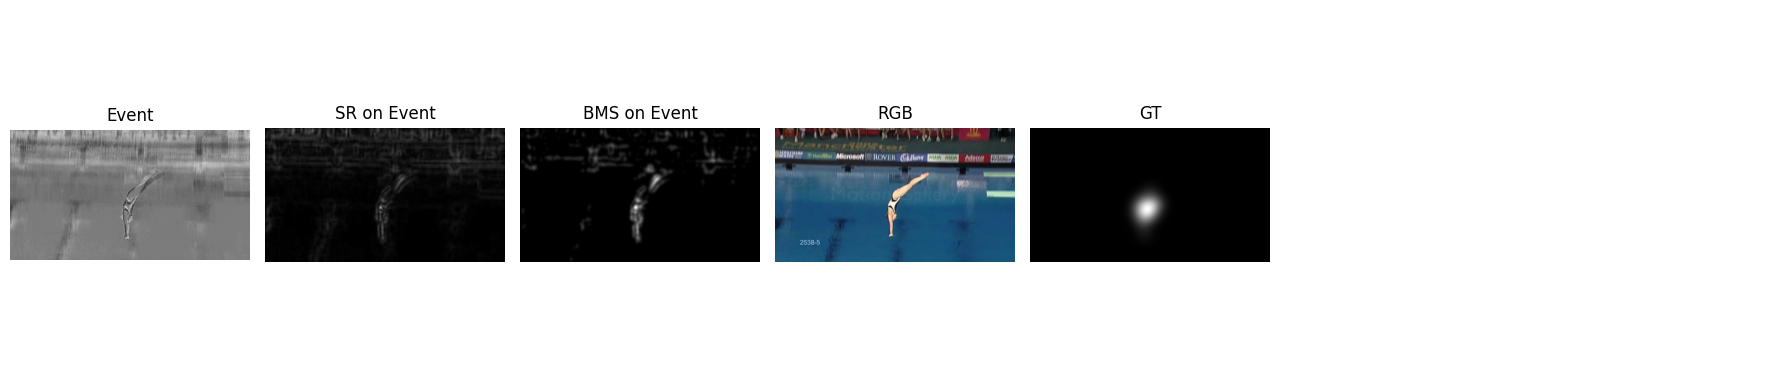

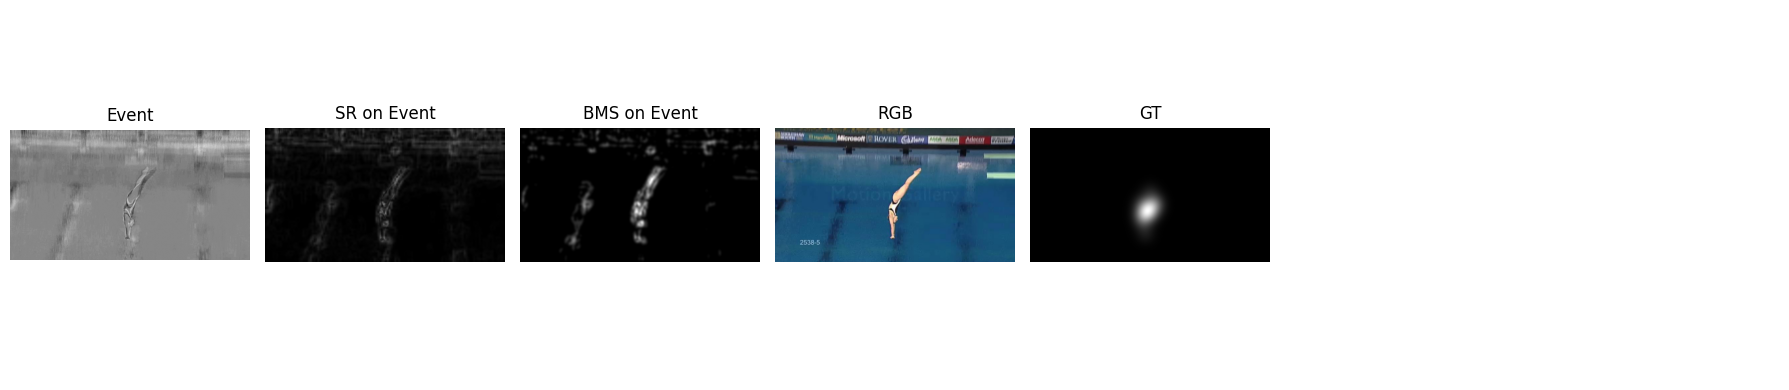

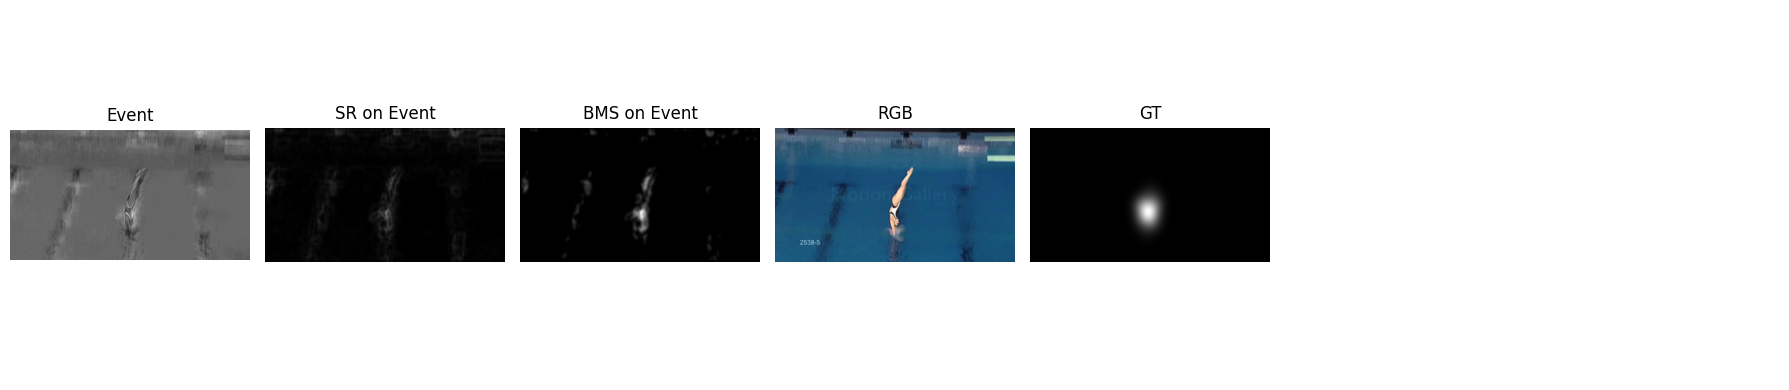

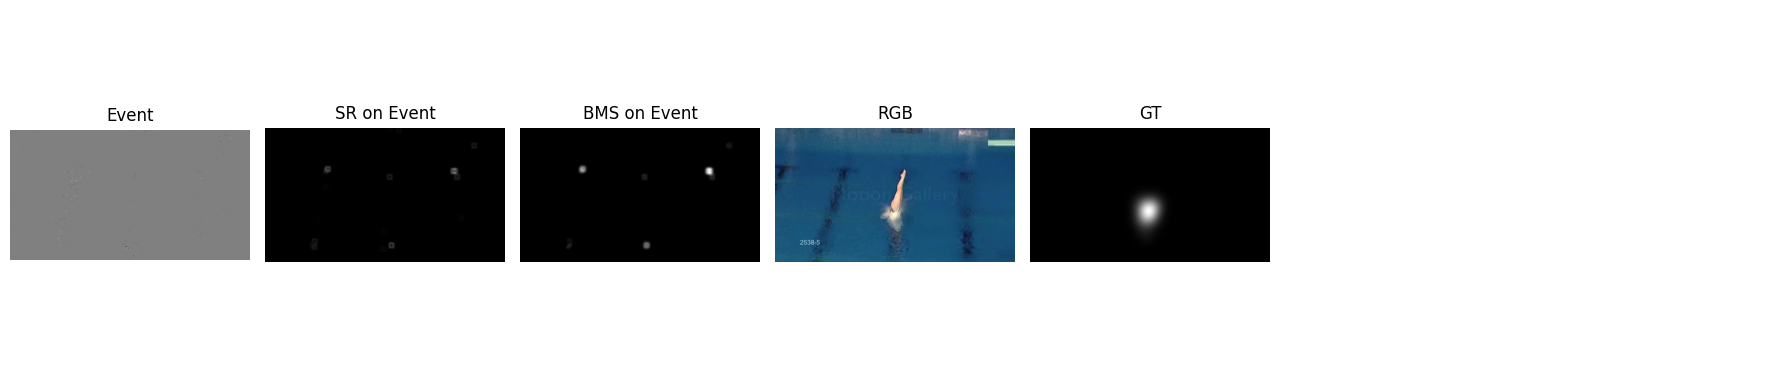

In [3]:
import numpy as np
import cv2
import importlib
import matplotlib.pyplot as plt
import matplotlib as mpl

import utils.evaluate_saliency as es
importlib.reload(es)

import utils.saliency_v1
importlib.reload(utils.saliency_v1)

from utils.saliency_v1 import spectral_residual_saliency, compute_bms_saliency

import utils.saliency_v2
importlib.reload(utils.saliency_v2)
from utils.saliency_v2 import spectral_residual_saliency_v2, compute_bms_saliency_v2
from utils.evaluate_saliency import KLdiv, AUC_Judd, NSS, sim, CC

import utils.attention_saliency
importlib.reload(utils.attention_saliency)
from utils.attention_saliency import spectral_residual_saliency_nn, compute_bms_saliency_nn



# ==========================================================
# LOOP THROUGH GENERATED FRAMES
# ==========================================================
for n in range(len(frames)):

    # -----------------------------
    # Event frame → grayscale RGB
    # -----------------------------
    event_frame = frames[n].astype(np.float32)

    ev_gray = (event_frame - event_frame.min()) / (
        event_frame.max() - event_frame.min() + 1e-8
    )
    ev_gray_255 = (ev_gray * 255).astype(np.uint8)
    ev_rgb = np.stack([ev_gray_255] * 3, axis=-1)

    # -----------------------------
    # Saliency on EVENT frame
    # -----------------------------
    # sr_map_on_event = spectral_residual_saliency(ev_rgb)
    # bms_map_on_event = compute_bms_saliency(ev_rgb)

    sr_map_on_event = spectral_residual_saliency_nn(ev_rgb)
    bms_map_on_event = compute_bms_saliency_nn(ev_rgb)

    # sr_map_on_event = spectral_residual_saliency_v2(ev_rgb)
    # bms_map_on_event = compute_bms_saliency_v2(ev_rgb)

    # -----------------------------
    # Original RGB image
    # -----------------------------
    img_orig = rgb_imgs[n]
    if img_orig.max() <= 1.0:
        img_orig = (img_orig * 255).astype(np.uint8)

    sr_map_on_rgb = spectral_residual_saliency(img_orig)
    bms_map_on_rgb = compute_bms_saliency(img_orig)

    # -----------------------------
    # Fixation & GT maps (ALREADY LOADED)
    # -----------------------------
    fixation_map = fix_maps[n]
    gtsal_map = gt_maps[n]

    if fixation_map is None or gtsal_map is None:
        print(f"[Skip frame {n}] Missing fixation or GT map")
        continue

    fixation_map = (fixation_map > 128).astype(np.uint8)

    gtsal_map = gtsal_map.astype(np.float32)
    gtsal_map = (gtsal_map - gtsal_map.min()) / (
        gtsal_map.max() - gtsal_map.min() + 1e-8
    )

    H, W = fixation_map.shape

    # -----------------------------
    # Resize saliency maps
    # -----------------------------
    sr_map_event_resized = cv2.resize(sr_map_on_event, (W, H))
    bms_map_event_resized = cv2.resize(bms_map_on_event, (W, H))
    sr_map_rgb_resized = cv2.resize(sr_map_on_rgb, (W, H))
    bms_map_rgb_resized = cv2.resize(bms_map_on_rgb, (W, H))

    gtsal_map_resized = cv2.resize(gtsal_map, (W, H))

    # -----------------------------
    # Metrics – EVENT
    # -----------------------------
    # auc_sr  = AUC_Judd(sr_map_event_resized, fixation_map)
    # nss_sr  = NSS(sr_map_event_resized, fixation_map)
    # kl_sr   = KLdiv(sr_map_event_resized, gtsal_map_resized)
    # cc_sr   = CC(sr_map_event_resized, gtsal_map_resized)
    # sim_sr  = sim(sr_map_event_resized, gtsal_map_resized)

    # auc_bms = AUC_Judd(bms_map_event_resized, fixation_map)
    # nss_bms = NSS(bms_map_event_resized, fixation_map)
    # kl_bms  = KLdiv(bms_map_event_resized, gtsal_map_resized)
    # cc_bms  = CC(bms_map_event_resized, gtsal_map_resized)
    # sim_bms = sim(bms_map_event_resized, gtsal_map_resized)

    # # -----------------------------
    # # Metrics – RGB
    # # -----------------------------
    # auc_sr_rgb  = AUC_Judd(sr_map_rgb_resized, fixation_map)
    # nss_sr_rgb  = NSS(sr_map_rgb_resized, fixation_map)
    # kl_sr_rgb   = KLdiv(sr_map_rgb_resized, gtsal_map_resized)
    # cc_sr_rgb   = CC(sr_map_rgb_resized, gtsal_map_resized)
    # sim_sr_rgb  = sim(sr_map_rgb_resized, gtsal_map_resized)

    # auc_bms_rgb = AUC_Judd(bms_map_rgb_resized, fixation_map)
    # nss_bms_rgb = NSS(bms_map_rgb_resized, fixation_map)
    # kl_bms_rgb  = KLdiv(bms_map_rgb_resized, gtsal_map_resized)
    # cc_bms_rgb  = CC(bms_map_rgb_resized, gtsal_map_resized)
    # sim_bms_rgb = sim(bms_map_rgb_resized, gtsal_map_resized)

    # # -----------------------------
    # # Print results
    # # -----------------------------
    # print(f"\nFrame {n}")
    # print(f" SR EVENT  | AUC {auc_sr:.3f} | NSS {nss_sr:.3f} | KL {kl_sr:.3f} | CC {cc_sr:.3f} | SIM {sim_sr:.3f}")
    # print(f" BMS EVENT | AUC {auc_bms:.3f} | NSS {nss_bms:.3f} | KL {kl_bms:.3f} | CC {cc_bms:.3f} | SIM {sim_bms:.3f}")
    # print(f" SR RGB    | AUC {auc_sr_rgb:.3f} | NSS {nss_sr_rgb:.3f} | KL {kl_sr_rgb:.3f} | CC {cc_sr_rgb:.3f} | SIM {sim_sr_rgb:.3f}")
    # print(f" BMS RGB   | AUC {auc_bms_rgb:.3f} | NSS {nss_bms_rgb:.3f} | KL {kl_bms_rgb:.3f} | CC {cc_bms_rgb:.3f} | SIM {sim_bms_rgb:.3f}")

    # -----------------------------
    # Visualization
    # -----------------------------
    fig, axes = plt.subplots(1, 7, figsize=(18, 4))
    axes[0].imshow(ev_gray, cmap="gray"); axes[0].set_title("Event")
    axes[1].imshow(sr_map_event_resized, cmap="gray"); axes[1].set_title("SR on Event",size=12)
    axes[2].imshow(bms_map_event_resized, cmap="gray"); axes[2].set_title("BMS on Event",size=12)
    axes[3].imshow(img_orig); axes[3].set_title("RGB",size=12)
    # axes[4].imshow(sr_map_rgb_resized, cmap="gray"); axes[4].set_title("SR on RGB",size=12)
    # axes[5].imshow(bms_map_rgb_resized, cmap="gray"); axes[5].set_title("BMS on RGB",size=12)
    axes[4].imshow(gtsal_map_resized, cmap="gray"); axes[4].set_title("GT",size=12)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
import os
import numpy as np
import cv2
import pandas as pd
import importlib
import time

from utils.event_data import generate_event_frames

import utils.saliency_v1
importlib.reload(utils.saliency_v1)
from utils.saliency_v1 import spectral_residual_saliency, compute_bms_saliency

import utils.attention_saliency
importlib.reload(utils.attention_saliency)
from utils.attention_saliency import spectral_residual_saliency_nn, compute_bms_saliency_nn

from utils.evaluate_saliency import KLdiv, AUC_Judd, NSS, sim, CC

# -------- Root folder containing all videos --------
root_dir = r".\ucf_test dataset"

# Values of n to test
n_values = [1, 2, 3, 4, 5]

for n_event in n_values:
    print(f"\n===== Running for n = {n_event} =====")

    video_folders = [
        os.path.join(root_dir, d)
        for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ]

    results = []

    for vid_folder in video_folders:
        print(f"Processing folder: {vid_folder}")

        events_dir = os.path.join(vid_folder, "events")
        npz_files = [f for f in os.listdir(events_dir) if f.endswith(".npz")]
        if len(npz_files) == 0:
            print("  No event npz, skip")
            continue

        event_npz = np.load(os.path.join(events_dir, npz_files[0]))
        t = event_npz["t"].astype(np.int64)
        x = event_npz["x"].astype(np.int16)
        y = event_npz["y"].astype(np.int16)
        p = event_npz["p"].astype(np.int8)

        # ==================================================
        # GENERATE FRAMES
        # ==================================================
        frames, rgb_imgs, fix_maps, gt_maps = generate_event_frames(
            x, y, p, t,
            rgb_dir=vid_folder,
            BIN_US=100_000_000,
            n=n_event,
            plot=False
        )

        metrics_sr = []
        metrics_bms = []
        metrics_sr_rgb = []
        metrics_bms_rgb = []

        sr_times = []
        bms_times = []
        sr_rgb_times = []
        bms_rgb_times = []

        for i in range(len(frames)):

            # Skip if missing GT or fixation
            if fix_maps[i] is None or gt_maps[i] is None:
                continue

            ev = frames[i].astype(np.float32)
            ev = (ev - ev.min()) / (ev.max() - ev.min() + 1e-8)
            ev_rgb = np.stack([(ev * 255).astype(np.uint8)] * 3, axis=-1)

            # -------- Event frame saliency --------
            start = time.time()
            sr_map = spectral_residual_saliency_nn(ev_rgb)
            sr_times.append(time.time() - start)

            start = time.time()
            bms_map = compute_bms_saliency_nn(ev_rgb)
            bms_times.append(time.time() - start)

            # -------- RGB saliency --------
            img_rgb = rgb_imgs[i]
            if img_rgb.max() <= 1:
                img_rgb = (img_rgb * 255).astype(np.uint8)

            start = time.time()
            sr_map_rgb = spectral_residual_saliency(img_rgb)
            sr_rgb_times.append(time.time() - start)

            start = time.time()
            bms_map_rgb = compute_bms_saliency(img_rgb)
            bms_rgb_times.append(time.time() - start)

            # -------- Fix & GT --------
            fix_map = (fix_maps[i] > 128).astype(np.uint8)
            gt_map = gt_maps[i].astype(np.float32)
            gt_map = (gt_map - gt_map.min()) / (gt_map.max() - gt_map.min() + 1e-8)

            H, W = fix_map.shape

            # -------- Resize maps --------
            sr_map = cv2.resize(sr_map, (W, H))
            bms_map = cv2.resize(bms_map, (W, H))
            sr_map_rgb = cv2.resize(sr_map_rgb, (W, H))
            bms_map_rgb = cv2.resize(bms_map_rgb, (W, H))
            gt_map = cv2.resize(gt_map, (W, H))

            # -------- Metrics EVENT --------
            metrics_sr.append([
                AUC_Judd(sr_map, fix_map),
                NSS(sr_map, fix_map),
                KLdiv(sr_map, gt_map),
                CC(sr_map, gt_map),
                sim(sr_map, gt_map)
            ])

            metrics_bms.append([
                AUC_Judd(bms_map, fix_map),
                NSS(bms_map, fix_map),
                KLdiv(bms_map, gt_map),
                CC(bms_map, gt_map),
                sim(bms_map, gt_map)
            ])

            # -------- Metrics RGB --------
            metrics_sr_rgb.append([
                AUC_Judd(sr_map_rgb, fix_map),
                NSS(sr_map_rgb, fix_map),
                KLdiv(sr_map_rgb, gt_map),
                CC(sr_map_rgb, gt_map),
                sim(sr_map_rgb, gt_map)
            ])

            metrics_bms_rgb.append([
                AUC_Judd(bms_map_rgb, fix_map),
                NSS(bms_map_rgb, fix_map),
                KLdiv(bms_map_rgb, gt_map),
                CC(bms_map_rgb, gt_map),
                sim(bms_map_rgb, gt_map)
            ])

        if len(metrics_sr) == 0:
            print("  No valid frames, skip")
            continue

        # -------- Mean metrics --------
        metrics_sr_mean = np.mean(metrics_sr, axis=0)
        metrics_bms_mean = np.mean(metrics_bms, axis=0)
        metrics_sr_rgb_mean = np.mean(metrics_sr_rgb, axis=0)
        metrics_bms_rgb_mean = np.mean(metrics_bms_rgb, axis=0)

        # -------- Mean inference times --------
        sr_time_mean = np.mean(sr_times) if len(sr_times) > 0 else 0
        bms_time_mean = np.mean(bms_times) if len(bms_times) > 0 else 0
        sr_rgb_time_mean = np.mean(sr_rgb_times) if len(sr_rgb_times) > 0 else 0
        bms_rgb_time_mean = np.mean(bms_rgb_times) if len(bms_rgb_times) > 0 else 0

        results.append({
            "video": os.path.basename(vid_folder),

            "sr_auc": metrics_sr_mean[0],
            "sr_nss": metrics_sr_mean[1],
            "sr_kl": metrics_sr_mean[2],
            "sr_cc": metrics_sr_mean[3],
            "sr_sim": metrics_sr_mean[4],

            "bms_auc": metrics_bms_mean[0],
            "bms_nss": metrics_bms_mean[1],
            "bms_kl": metrics_bms_mean[2],
            "bms_cc": metrics_bms_mean[3],
            "bms_sim": metrics_bms_mean[4],

            "sr_rgb_auc": metrics_sr_rgb_mean[0],
            "sr_rgb_nss": metrics_sr_rgb_mean[1],
            "sr_rgb_kl": metrics_sr_rgb_mean[2],
            "sr_rgb_cc": metrics_sr_rgb_mean[3],
            "sr_rgb_sim": metrics_sr_rgb_mean[4],

            "bms_rgb_auc": metrics_bms_rgb_mean[0],
            "bms_rgb_nss": metrics_bms_rgb_mean[1],
            "bms_rgb_kl": metrics_bms_rgb_mean[2],
            "bms_rgb_cc": metrics_bms_rgb_mean[3],
            "bms_rgb_sim": metrics_bms_rgb_mean[4],

            # -------- Inference time (seconds per frame) --------
            "sr_time": sr_time_mean,
            "bms_time": bms_time_mean,
            "sr_rgb_time": sr_rgb_time_mean,
            "bms_rgb_time": bms_rgb_time_mean
        })

    # -------- Save CSV --------
    df = pd.DataFrame(results)
    csv_name = f"ucf_metrics_summary_n{n_event}_attention.csv"
    df.to_csv(csv_name, index=False)
    print(f"Saved metrics and inference times to {csv_name}")


===== Running for n = 1 =====
Processing folder: .\ucf_test dataset\Diving-Side-001
Processing folder: .\ucf_test dataset\Diving-Side-002
Processing folder: .\ucf_test dataset\Diving-Side-003
Processing folder: .\ucf_test dataset\Diving-Side-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-001
Processing folder: .\ucf_test dataset\Golf-Swing-Back-002
Processing folder: .\ucf_test dataset\Golf-Swing-Back-003
Processing folder: .\ucf_test dataset\Golf-Swing-Back-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-005
Processing folder: .\ucf_test dataset\Golf-Swing-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-002
Processing folder: .\ucf_test dataset\Kicking-Front-003
Processing folder: .\ucf_test dataset\Kicking-Front-004
Processing folder: .\ucf_test dataset\Kicking-Front-005
Processing folder: .\ucf_test dataset\Kicking-Front-006
Processing folder: .\ucf_test dataset\Lifting-001
Processing folder:

In [ ]:
import os
import numpy as np
import cv2
import pandas as pd
import importlib
import time

from utils.event_data import generate_event_frames

import utils.saliency_v1
importlib.reload(utils.saliency_v1)
from utils.saliency_v1 import spectral_residual_saliency, compute_bms_saliency

import utils.saliency_v2 as saliency_v2
importlib.reload(saliency_v2)
from utils.saliency_v2 import spectral_residual_saliency_v2, compute_bms_saliency_v2

from utils.evaluate_saliency import KLdiv, AUC_Judd, NSS, sim, CC

# -------- Root folder chứa tất cả videos --------
root_dir = r".\ucf_test dataset"

# Các giá trị n muốn thử
n_values = [1, 2, 3, 4, 5]

for n_event in n_values:
    print(f"\n===== Running for n = {n_event} =====")

    video_folders = [
        os.path.join(root_dir, d)
        for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ]

    results = []

    for vid_folder in video_folders:
        print(f"Processing folder: {vid_folder}")

        events_dir = os.path.join(vid_folder, "events")
        npz_files = [f for f in os.listdir(events_dir) if f.endswith(".npz")]
        if len(npz_files) == 0:
            print("  No event npz, skip")
            continue

        event_npz = np.load(os.path.join(events_dir, npz_files[0]))
        t = event_npz["t"].astype(np.int64)
        x = event_npz["x"].astype(np.int16)
        y = event_npz["y"].astype(np.int16)
        p = event_npz["p"].astype(np.int8)

        # ==================================================
        # GENERATE FRAMES
        # ==================================================
        frames, rgb_imgs, fix_maps, gt_maps = generate_event_frames(
            x, y, p, t,
            rgb_dir=vid_folder,
            BIN_US=100_000_000,
            n=n_event,
            plot=False
        )

        metrics_sr = []
        metrics_bms = []
        metrics_sr_rgb = []
        metrics_bms_rgb = []

        # -------- Lists to store inference times --------
        sr_times = []
        bms_times = []
        sr_rgb_times = []
        bms_rgb_times = []

        for i in range(len(frames)):

            # Skip nếu thiếu GT hoặc fixation
            if fix_maps[i] is None or gt_maps[i] is None:
                continue

            ev = frames[i].astype(np.float32)
            ev = (ev - ev.min()) / (ev.max() - ev.min() + 1e-8)
            ev_rgb = np.stack([(ev * 255).astype(np.uint8)] * 3, axis=-1)

            # -------- Saliency EVENT (v2) --------
            start = time.time()
            sr_map = spectral_residual_saliency_v2(ev_rgb)
            sr_times.append(time.time() - start)

            start = time.time()
            bms_map = compute_bms_saliency_v2(ev_rgb)
            bms_times.append(time.time() - start)

            # -------- Saliency RGB (v1) --------
            img_rgb = rgb_imgs[i]
            if img_rgb.max() <= 1:
                img_rgb = (img_rgb * 255).astype(np.uint8)

            start = time.time()
            sr_map_rgb = spectral_residual_saliency(img_rgb)
            sr_rgb_times.append(time.time() - start)

            start = time.time()
            bms_map_rgb = compute_bms_saliency(img_rgb)
            bms_rgb_times.append(time.time() - start)

            # -------- Fix & GT --------
            fix_map = (fix_maps[i] > 128).astype(np.uint8)
            gt_map = gt_maps[i].astype(np.float32)
            gt_map = (gt_map - gt_map.min()) / (gt_map.max() - gt_map.min() + 1e-8)

            H, W = fix_map.shape

            # -------- Resize --------
            sr_map = cv2.resize(sr_map, (W, H))
            bms_map = cv2.resize(bms_map, (W, H))
            sr_map_rgb = cv2.resize(sr_map_rgb, (W, H))
            bms_map_rgb = cv2.resize(bms_map_rgb, (W, H))
            gt_map = cv2.resize(gt_map, (W, H))

            # -------- Metrics EVENT --------
            metrics_sr.append([
                AUC_Judd(sr_map, fix_map),
                NSS(sr_map, fix_map),
                KLdiv(sr_map, gt_map),
                CC(sr_map, gt_map),
                sim(sr_map, gt_map)
            ])

            metrics_bms.append([
                AUC_Judd(bms_map, fix_map),
                NSS(bms_map, fix_map),
                KLdiv(bms_map, gt_map),
                CC(bms_map, gt_map),
                sim(bms_map, gt_map)
            ])

            # -------- Metrics RGB --------
            metrics_sr_rgb.append([
                AUC_Judd(sr_map_rgb, fix_map),
                NSS(sr_map_rgb, fix_map),
                KLdiv(sr_map_rgb, gt_map),
                CC(sr_map_rgb, gt_map),
                sim(sr_map_rgb, gt_map)
            ])

            metrics_bms_rgb.append([
                AUC_Judd(bms_map_rgb, fix_map),
                NSS(bms_map_rgb, fix_map),
                KLdiv(bms_map_rgb, gt_map),
                CC(bms_map_rgb, gt_map),
                sim(bms_map_rgb, gt_map)
            ])

        if len(metrics_sr) == 0:
            print("  No valid frames, skip")
            continue

        # -------- Mean metrics --------
        metrics_sr_mean = np.mean(metrics_sr, axis=0)
        metrics_bms_mean = np.mean(metrics_bms, axis=0)
        metrics_sr_rgb_mean = np.mean(metrics_sr_rgb, axis=0)
        metrics_bms_rgb_mean = np.mean(metrics_bms_rgb, axis=0)

        # -------- Mean inference times --------
        sr_time_mean = np.mean(sr_times) if len(sr_times) > 0 else 0
        bms_time_mean = np.mean(bms_times) if len(bms_times) > 0 else 0
        sr_rgb_time_mean = np.mean(sr_rgb_times) if len(sr_rgb_times) > 0 else 0
        bms_rgb_time_mean = np.mean(bms_rgb_times) if len(bms_rgb_times) > 0 else 0

        results.append({
            "video": os.path.basename(vid_folder),

            "sr_auc": metrics_sr_mean[0],
            "sr_nss": metrics_sr_mean[1],
            "sr_kl": metrics_sr_mean[2],
            "sr_cc": metrics_sr_mean[3],
            "sr_sim": metrics_sr_mean[4],

            "bms_auc": metrics_bms_mean[0],
            "bms_nss": metrics_bms_mean[1],
            "bms_kl": metrics_bms_mean[2],
            "bms_cc": metrics_bms_mean[3],
            "bms_sim": metrics_bms_mean[4],

            "sr_rgb_auc": metrics_sr_rgb_mean[0],
            "sr_rgb_nss": metrics_sr_rgb_mean[1],
            "sr_rgb_kl": metrics_sr_rgb_mean[2],
            "sr_rgb_cc": metrics_sr_rgb_mean[3],
            "sr_rgb_sim": metrics_sr_rgb_mean[4],

            "bms_rgb_auc": metrics_bms_rgb_mean[0],
            "bms_rgb_nss": metrics_bms_rgb_mean[1],
            "bms_rgb_kl": metrics_bms_rgb_mean[2],
            "bms_rgb_cc": metrics_bms_rgb_mean[3],
            "bms_rgb_sim": metrics_bms_rgb_mean[4],

            # -------- Inference time (seconds per frame) --------
            "sr_time": sr_time_mean,
            "bms_time": bms_time_mean,
            "sr_rgb_time": sr_rgb_time_mean,
            "bms_rgb_time": bms_rgb_time_mean
        })

    # -------- Save CSV --------
    df = pd.DataFrame(results)
    csv_name = f"ucf_metrics_summary_n{n_event}_v2_with_time.csv"
    df.to_csv(csv_name, index=False)
    print(f"Saved metrics and inference times to {csv_name}")


===== Running for n = 1 =====
Processing folder: .\ucf_test dataset\Diving-Side-001
Processing folder: .\ucf_test dataset\Diving-Side-002
Processing folder: .\ucf_test dataset\Diving-Side-003
Processing folder: .\ucf_test dataset\Diving-Side-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-001
Processing folder: .\ucf_test dataset\Golf-Swing-Back-002
Processing folder: .\ucf_test dataset\Golf-Swing-Back-003
Processing folder: .\ucf_test dataset\Golf-Swing-Back-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-005
Processing folder: .\ucf_test dataset\Golf-Swing-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-002
Processing folder: .\ucf_test dataset\Kicking-Front-003
Processing folder: .\ucf_test dataset\Kicking-Front-004
Processing folder: .\ucf_test dataset\Kicking-Front-005
Processing folder: .\ucf_test dataset\Kicking-Front-006
Processing folder: .\ucf_test dataset\Lifting-001
Processing folder:

In [ ]:
import os
import numpy as np
import cv2
import pandas as pd
import importlib
import time

from utils.event_data import generate_event_frames

import utils.saliency_v1
importlib.reload(utils.saliency_v1)
from utils.saliency_v1 import spectral_residual_saliency, compute_bms_saliency

from utils.evaluate_saliency import KLdiv, AUC_Judd, NSS, sim, CC

# -------- Root folder chứa tất cả videos --------
root_dir = r".\ucf_test dataset"

# Các giá trị n muốn thử
n_values = [1, 2, 3, 4, 5]

for n_event in n_values:
    print(f"\n===== Running for n = {n_event} =====")

    video_folders = [
        os.path.join(root_dir, d)
        for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ]

    results = []

    for vid_folder in video_folders:
        print(f"Processing folder: {vid_folder}")

        events_dir = os.path.join(vid_folder, "events")
        npz_files = [f for f in os.listdir(events_dir) if f.endswith(".npz")]
        if len(npz_files) == 0:
            print("  No event npz, skip")
            continue

        event_npz = np.load(os.path.join(events_dir, npz_files[0]))
        t = event_npz["t"].astype(np.int64)
        x = event_npz["x"].astype(np.int16)
        y = event_npz["y"].astype(np.int16)
        p = event_npz["p"].astype(np.int8)

        # ==================================================
        # GENERATE FRAMES
        # ==================================================
        frames, rgb_imgs, fix_maps, gt_maps = generate_event_frames(
            x, y, p, t,
            rgb_dir=vid_folder,
            BIN_US=100_000_000,
            n=n_event,
            plot=False
        )

        metrics_sr = []
        metrics_bms = []
        metrics_sr_rgb = []
        metrics_bms_rgb = []

        # -------- Lists to store inference times --------
        sr_times = []
        bms_times = []
        sr_rgb_times = []
        bms_rgb_times = []

        for i in range(len(frames)):

            # Skip nếu thiếu GT hoặc fixation
            if fix_maps[i] is None or gt_maps[i] is None:
                continue

            ev = frames[i].astype(np.float32)
            ev = (ev - ev.min()) / (ev.max() - ev.min() + 1e-8)
            ev_rgb = np.stack([(ev * 255).astype(np.uint8)] * 3, axis=-1)

            # -------- Saliency EVENT (v1) --------
            start = time.time()
            sr_map = spectral_residual_saliency(ev_rgb)
            sr_times.append(time.time() - start)

            start = time.time()
            bms_map = compute_bms_saliency(ev_rgb)
            bms_times.append(time.time() - start)

            # -------- Saliency RGB (v1) --------
            img_rgb = rgb_imgs[i]
            if img_rgb.max() <= 1:
                img_rgb = (img_rgb * 255).astype(np.uint8)

            start = time.time()
            sr_map_rgb = spectral_residual_saliency(img_rgb)
            sr_rgb_times.append(time.time() - start)

            start = time.time()
            bms_map_rgb = compute_bms_saliency(img_rgb)
            bms_rgb_times.append(time.time() - start)

            # -------- Fix & GT --------
            fix_map = (fix_maps[i] > 128).astype(np.uint8)
            gt_map = gt_maps[i].astype(np.float32)
            gt_map = (gt_map - gt_map.min()) / (gt_map.max() - gt_map.min() + 1e-8)

            H, W = fix_map.shape

            # -------- Resize --------
            sr_map = cv2.resize(sr_map, (W, H))
            bms_map = cv2.resize(bms_map, (W, H))
            sr_map_rgb = cv2.resize(sr_map_rgb, (W, H))
            bms_map_rgb = cv2.resize(bms_map_rgb, (W, H))
            gt_map = cv2.resize(gt_map, (W, H))

            # -------- Metrics EVENT --------
            metrics_sr.append([
                AUC_Judd(sr_map, fix_map),
                NSS(sr_map, fix_map),
                KLdiv(sr_map, gt_map),
                CC(sr_map, gt_map),
                sim(sr_map, gt_map)
            ])

            metrics_bms.append([
                AUC_Judd(bms_map, fix_map),
                NSS(bms_map, fix_map),
                KLdiv(bms_map, gt_map),
                CC(bms_map, gt_map),
                sim(bms_map, gt_map)
            ])

            # -------- Metrics RGB --------
            metrics_sr_rgb.append([
                AUC_Judd(sr_map_rgb, fix_map),
                NSS(sr_map_rgb, fix_map),
                KLdiv(sr_map_rgb, gt_map),
                CC(sr_map_rgb, gt_map),
                sim(sr_map_rgb, gt_map)
            ])

            metrics_bms_rgb.append([
                AUC_Judd(bms_map_rgb, fix_map),
                NSS(bms_map_rgb, fix_map),
                KLdiv(bms_map_rgb, gt_map),
                CC(bms_map_rgb, gt_map),
                sim(bms_map_rgb, gt_map)
            ])

        if len(metrics_sr) == 0:
            print("  No valid frames, skip")
            continue

        # -------- Mean metrics --------
        metrics_sr_mean = np.mean(metrics_sr, axis=0)
        metrics_bms_mean = np.mean(metrics_bms, axis=0)
        metrics_sr_rgb_mean = np.mean(metrics_sr_rgb, axis=0)
        metrics_bms_rgb_mean = np.mean(metrics_bms_rgb, axis=0)

        # -------- Mean inference times --------
        sr_time_mean = np.mean(sr_times) if len(sr_times) > 0 else 0
        bms_time_mean = np.mean(bms_times) if len(bms_times) > 0 else 0
        sr_rgb_time_mean = np.mean(sr_rgb_times) if len(sr_rgb_times) > 0 else 0
        bms_rgb_time_mean = np.mean(bms_rgb_times) if len(bms_rgb_times) > 0 else 0

        results.append({
            "video": os.path.basename(vid_folder),

            "sr_auc": metrics_sr_mean[0],
            "sr_nss": metrics_sr_mean[1],
            "sr_kl": metrics_sr_mean[2],
            "sr_cc": metrics_sr_mean[3],
            "sr_sim": metrics_sr_mean[4],

            "bms_auc": metrics_bms_mean[0],
            "bms_nss": metrics_bms_mean[1],
            "bms_kl": metrics_bms_mean[2],
            "bms_cc": metrics_bms_mean[3],
            "bms_sim": metrics_bms_mean[4],

            "sr_rgb_auc": metrics_sr_rgb_mean[0],
            "sr_rgb_nss": metrics_sr_rgb_mean[1],
            "sr_rgb_kl": metrics_sr_rgb_mean[2],
            "sr_rgb_cc": metrics_sr_rgb_mean[3],
            "sr_rgb_sim": metrics_sr_rgb_mean[4],

            "bms_rgb_auc": metrics_bms_rgb_mean[0],
            "bms_rgb_nss": metrics_bms_rgb_mean[1],
            "bms_rgb_kl": metrics_bms_rgb_mean[2],
            "bms_rgb_cc": metrics_bms_rgb_mean[3],
            "bms_rgb_sim": metrics_bms_rgb_mean[4],

            # -------- Inference time (seconds per frame) --------
            "sr_time": sr_time_mean,
            "bms_time": bms_time_mean,
            "sr_rgb_time": sr_rgb_time_mean,
            "bms_rgb_time": bms_rgb_time_mean
        })

    # -------- Save CSV --------
    df = pd.DataFrame(results)
    csv_name = f"ucf_metrics_summary_n{n_event}_v1_with_time.csv"
    df.to_csv(csv_name, index=False)
    print(f"Saved metrics and inference times to {csv_name}")


===== Running for n = 1 =====
Processing folder: .\ucf_test dataset\Diving-Side-001
Processing folder: .\ucf_test dataset\Diving-Side-002
Processing folder: .\ucf_test dataset\Diving-Side-003
Processing folder: .\ucf_test dataset\Diving-Side-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-001
Processing folder: .\ucf_test dataset\Golf-Swing-Back-002
Processing folder: .\ucf_test dataset\Golf-Swing-Back-003
Processing folder: .\ucf_test dataset\Golf-Swing-Back-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-005
Processing folder: .\ucf_test dataset\Golf-Swing-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-002
Processing folder: .\ucf_test dataset\Kicking-Front-003
Processing folder: .\ucf_test dataset\Kicking-Front-004
Processing folder: .\ucf_test dataset\Kicking-Front-005
Processing folder: .\ucf_test dataset\Kicking-Front-006
Processing folder: .\ucf_test dataset\Lifting-001
Processing folder:

d:\Python_Projects\PER_PROJECT_2025_039\utils\saliency_v1.py:100: RuntimeWarning: invalid value encountered in divide
  attn_map /= attn_map.max() / 255
d:\Python_Projects\PER_PROJECT_2025_039\utils\saliency_v1.py:102: RuntimeWarning: invalid value encountered in cast
  return attn_map.astype(np.uint8)


Processing folder: .\ucf_test dataset\Walk-Front-005
Processing folder: .\ucf_test dataset\Walk-Front-006
Processing folder: .\ucf_test dataset\Walk-Front-007
Saved metrics to ucf_metrics_summary_n1_v1.csv

===== Running for n = 2 =====
Processing folder: .\ucf_test dataset\Diving-Side-001
Processing folder: .\ucf_test dataset\Diving-Side-002
Processing folder: .\ucf_test dataset\Diving-Side-003
Processing folder: .\ucf_test dataset\Diving-Side-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-001
Processing folder: .\ucf_test dataset\Golf-Swing-Back-002
Processing folder: .\ucf_test dataset\Golf-Swing-Back-003
Processing folder: .\ucf_test dataset\Golf-Swing-Back-004
Processing folder: .\ucf_test dataset\Golf-Swing-Back-005
Processing folder: .\ucf_test dataset\Golf-Swing-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-001
Processing folder: .\ucf_test dataset\Kicking-Front-002
Processing folder: .\ucf_test dataset\Kicking-Front-003
Processing folder: .\ucf_test 

In [1]:
import psutil
import platform

try:
    import cpuinfo
except ImportError:
    cpuinfo = None

print("===== SYSTEM INFO =====")
# CPU
print("CPU:", platform.processor())
if cpuinfo:
    info = cpuinfo.get_cpu_info()
    print("CPU Name:", info.get("brand_raw", "Unknown"))
    print("Cores:", psutil.cpu_count(logical=False))
    print("Logical processors:", psutil.cpu_count(logical=True))
else:
    print("Cores:", psutil.cpu_count(logical=False))
    print("Logical processors:", psutil.cpu_count(logical=True))

# RAM
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024 ** 3):.2f} GB")
print(f"Available RAM: {ram.available / (1024 ** 3):.2f} GB")
print(f"Used RAM: {ram.used / (1024 ** 3):.2f} GB")
print("========================")

===== SYSTEM INFO =====
CPU: AMD64 Family 23 Model 104 Stepping 1, AuthenticAMD
Cores: 6
Logical processors: 12
Total RAM: 7.35 GB
Available RAM: 0.99 GB
Used RAM: 6.36 GB
